In [ ]:
import pandas as pd
import numpy as np
import altair as alt

# Load and preprocess
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])
df['year'] = df['date'].dt.year
df = df[df['year'] != 2020]
df = df.sort_values('date')
df['ordinal_day'] = df['date'].dt.dayofyear
df['month_day'] = df['date'].dt.strftime('%m-%d')

# Create base columns
df['demand_scaled'] = df['demand']

# Generate Altair base DataFrame (without smoothing)
df_base = df[['date', 'year', 'ordinal_day', 'month_day', 'demand', 'demand_scaled']].copy()

# --- Interactivity Controls ---
start_slider = alt.binding_range(min=1, max=366, step=1, name='Start Day: ')
end_slider = alt.binding_range(min=1, max=366, step=1, name='End Day: ')
scale_slider = alt.binding_range(min=0.25, max=2.0, step=0.01, name='Final Scale: ')
window_slider = alt.binding_range(min=1, max=90, step=1, name='Rolling Window: ')

start_param = alt.param(value=182, bind=start_slider, name='start_day')
end_param = alt.param(value=250, bind=end_slider, name='end_day')
scale_param = alt.param(value=0.85, bind=scale_slider, name='scaling')
window_param = alt.param(value=20, bind=window_slider, name='smooth')

# Chart with calculations for scaled demand
base_chart = alt.Chart(df_base).transform_calculate(
    in_range="datum.year == 2018 && datum.ordinal_day >= start_day && datum.ordinal_day <= end_day"
).transform_calculate(
    scale_factor=(
        "datum.in_range ? "
        "(1.0 - ((datum.ordinal_day - start_day) / (end_day - start_day)) * (1.0 - scaling))"
        " : 1.0"
    )
).transform_calculate(
    demand_scaled="datum.year == 2018 ? datum.demand * datum.scale_factor : datum.demand"
).transform_window(
    smoothed_scaled="mean(demand_scaled)",
    sort=[{"field": "date"}],
    frame=[-10, 10],  # default; can't use a parameter here
    groupby=["year"]
).transform_window(
    smoothed_original="mean(demand)",
    sort=[{"field": "date"}],
    frame=[-10, 10],  # default
    groupby=["year"]
)

# Smoothed scaled line (highlighted)
scaled_line = base_chart.mark_line().encode(
    x=alt.X('month_day:N', title='Date'),
    y=alt.Y('smoothed_scaled:Q', title='Smoothed Demand'),
    color=alt.Color('year:N', scale=alt.Scale(scheme='tableau10')),
    opacity=alt.condition("datum.year == 2018", alt.value(1.0), alt.value(0.35)),
    tooltip=['date:T', 'year:N', 'smoothed_scaled:Q']
)

# Smoothed original (dashed line)
original_line = base_chart.mark_line(strokeDash=[4, 4]).encode(
    x='month_day:N',
    y='smoothed_original:Q',
    color=alt.Color('year:N', scale=alt.Scale(scheme='tableau10'), legend=None),
    opacity=alt.condition("datum.year == 2017", alt.value(1.0), alt.value(0.35)),
    tooltip=['date:T', 'year:N', 'smoothed_original:Q']
)

# Final interactive chart
chart = alt.layer(original_line, scaled_line).add_params(
    start_param,
    end_param,
    scale_param,
    # Note: window_param is not used inside .transform_window
).resolve_scale(
    y='shared'
).properties(
    width=800,
    height=250,
    title='Electricity Demand (Smoothed): Original vs Scaled with Interactive Controls'
)

chart.save('results/imgs/energy_2018.html')

In [ ]:
import pandas as pd
import numpy as np
import altair as alt

# Load and preprocess
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])
df['year'] = df['date'].dt.year
df = df[df['year'] != 2020]
df = df.sort_values('date')
df['ordinal_day'] = df['date'].dt.dayofyear
df['month_day'] = df['date'].dt.strftime('%m-%d')

# Base DataFrame
df['demand_scaled'] = df['demand']
df_base = df[['date', 'year', 'ordinal_day', 'month_day', 'demand', 'demand_scaled']].copy()

# --- Interactivity Controls ---
start_slider = alt.binding_range(min=1, max=366, step=1, name='Start Day: ')
end_slider = alt.binding_range(min=1, max=366, step=1, name='End Day: ')
scale_slider = alt.binding_range(min=0.25, max=2.0, step=0.01, name='Final Scale: ')

start_param = alt.param(value=182, bind=start_slider, name='start_day')
end_param = alt.param(value=250, bind=end_slider, name='end_day')
scale_param = alt.param(value=0.85, bind=scale_slider, name='scaling')

# --- Chart for 2018 only with scaling ---
chart_2018 = alt.Chart(df_base).transform_filter(
    alt.datum.year == 2018
).transform_calculate(
    in_range="datum.ordinal_day >= start_day && datum.ordinal_day <= end_day"
).transform_calculate(
    scale_factor=(
        "datum.in_range ? "
        "(1.0 - ((datum.ordinal_day - start_day) / (end_day - start_day)) * (1.0 - scaling))"
        " : 1.0"
    )
).transform_calculate(
    demand_scaled="datum.demand * datum.scale_factor"
).transform_window(
    smoothed_scaled="mean(demand_scaled)",
    sort=[{"field": "date"}],
    frame=[-10, 10]
).mark_line(color='red').encode(
    x=alt.X('month_day:N', title='Date'),
    y=alt.Y('smoothed_scaled:Q', title='Demand (Smoothed)'),
    tooltip=['date:T', 'smoothed_scaled:Q']
)

# --- Mean and Confidence Interval from other years ---
df_other = df_base[df_base['year'] != 2018].copy()

# Smooth demand per year
df_other['smoothed'] = df_other.groupby('year')['demand'].transform(
    lambda x: x.rolling(21, center=True, min_periods=1).mean()
)

# Aggregate: Mean and CI
agg_df = df_other.groupby('month_day').agg(
    mean_demand=('smoothed', 'mean'),
    std_demand=('smoothed', 'std')
).reset_index()
agg_df['ci_upper'] = agg_df['mean_demand'] + 1.96 * agg_df['std_demand']
agg_df['ci_lower'] = agg_df['mean_demand'] - 1.96 * agg_df['std_demand']

# CI area chart
ci_band = alt.Chart(agg_df).mark_area(opacity=0.3, color='lightgray').encode(
    x='month_day:N',
    y='ci_lower:Q',
    y2='ci_upper:Q'
)

# Mean line chart
mean_line = alt.Chart(agg_df).mark_line(strokeDash=[4, 4], color='gray').encode(
    x='month_day:N',
    y='mean_demand:Q'
)

# Final composition
final_chart = alt.layer(
    ci_band,
    mean_line,
    chart_2018
).add_params(
    start_param, end_param, scale_param
).properties(
    width=800,
    height=300,
    title='Electricity Demand: 2018 vs Historical Mean with Confidence Interval'
)

final_chart.save('results/imgs/energy_2018_CI.html')

In [2]:
df

,date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday,year,month_day,month,demand_scaled,demand_smooth_original,demand_smooth_scaled
0,2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,N,Y,2015,01-01,1,99635.030,99635.030000,99635.030000
1,2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,N,N,2015,01-02,1,129606.010,114620.520000,114620.520000
2,2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,N,N,2015,01-03,1,142300.540,123847.193333,123847.193333
3,2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,N,N,2015,01-04,1,104330.715,118968.073750,118968.073750
4,2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,N,N,2015,01-05,1,118132.200,118800.899000,118800.899000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1821,2019-12-27,107256.065,56.122451,107256.065,56.122451,0.000,0.000000,0.000000,13.6,23.9,31.6,0.0,N,N,2019,12-27,12,107256.065,109261.128667,109261.128667
1822,2019-12-28,113521.685,63.295449,113521.685,63.295449,0.000,0.000000,0.000000,16.7,28.4,20.6,0.0,N,N,2019,12-28,12,113521.685,109288.366667,109288.366667
1823,2019-12-29,118293.525,87.686689,118293.525,87.686689,0.000,0.000000,0.000000,16.8,33.2,31.9,0.0,N,N,2019,12-29,12,118293.525,109303.663250,109303.663250
1824,2019-12-30,140410.125,295.829202,140410.125,295.829202,0.000,0.000000,0.000000,19.7,40.8,18.8,0.0,N,N,2019,12-30,12,140410.125,109614.617417,109614.617417


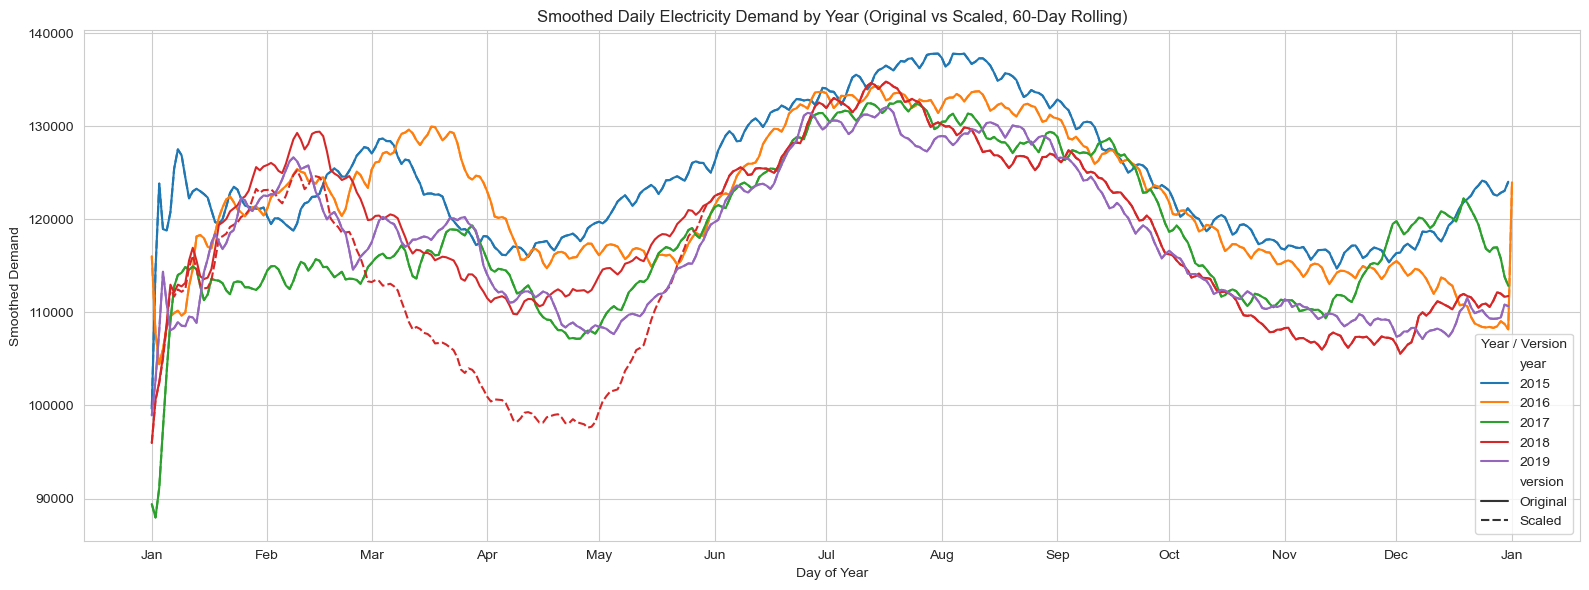

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates

# Load the CSV data
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])

# Extract date components
df['year'] = df['date'].dt.year
df['month_day'] = df['date'].dt.strftime('%m-%d')
df['month'] = df['date'].dt.month

# Sort for rolling operations
df = df.sort_values(['year', 'date'])
df = df[df['year'] != 2020]  # Filter out 2020

# --- NEW: Create a scaled version of the demand ---
df['demand_scaled'] = df['demand']  # start with original

# Define 3 periods for 2017
periods = [
    ("2018-01-01", "2018-04-30", "P1"),
    ("2018-05-01", "2018-08-31", "P2"),
    ("2018-09-01", "2018-12-31", "P3"),
]
(start, end, period_id) = periods[0]

# Mask for 2017 Jul–Dec
mask = (
    (df['date'] >= pd.to_datetime(start)) &
    (df['date'] <= pd.to_datetime(end)) &
    (df['date'].dt.year == 2018)
)

transition_dates = df.loc[mask, 'date']
n = len(transition_dates)

# Scaling factors
scaling_factors = np.linspace(1.0, 0.85, n)

# Apply scaling to new column (only 2017 Jul–Dec)
df.loc[mask, 'demand_scaled'] = df.loc[mask, 'demand'] * scaling_factors

# --- Smooth both original and scaled values ---
df['demand_smooth_original'] = df.groupby('year')['demand'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
df['demand_smooth_scaled'] = df.groupby('year')['demand_scaled'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# --- Prepare for plotting ---
df_plot = pd.melt(
    df,
    id_vars=['date', 'year', 'month_day'],
    value_vars=['demand_smooth_original', 'demand_smooth_scaled'],
    var_name='version',
    value_name='demand_smooth'
)

# Rename versions for prettier legend
df_plot['version'] = df_plot['version'].map({
    'demand_smooth_original': 'Original',
    'demand_smooth_scaled': 'Scaled'
})

# Aggregate for smoother line
df_plot = df_plot.groupby(['version', 'year', 'month_day'], as_index=False)['demand_smooth'].mean()

# --- Plot ---
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")
plt.gca().set_xticklabels([])

sns.lineplot(
    data=df_plot,
    x='month_day',
    y='demand_smooth',
    hue='year',
    style='version',
    palette='tab10'
)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # e.g., Jan, Feb, ...


plt.title('Smoothed Daily Electricity Demand by Year (Original vs Scaled, 60-Day Rolling)')
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Demand')
# plt.xticks(rotation=45)
plt.legend(title='Year / Version')
plt.tight_layout()
plt.show()

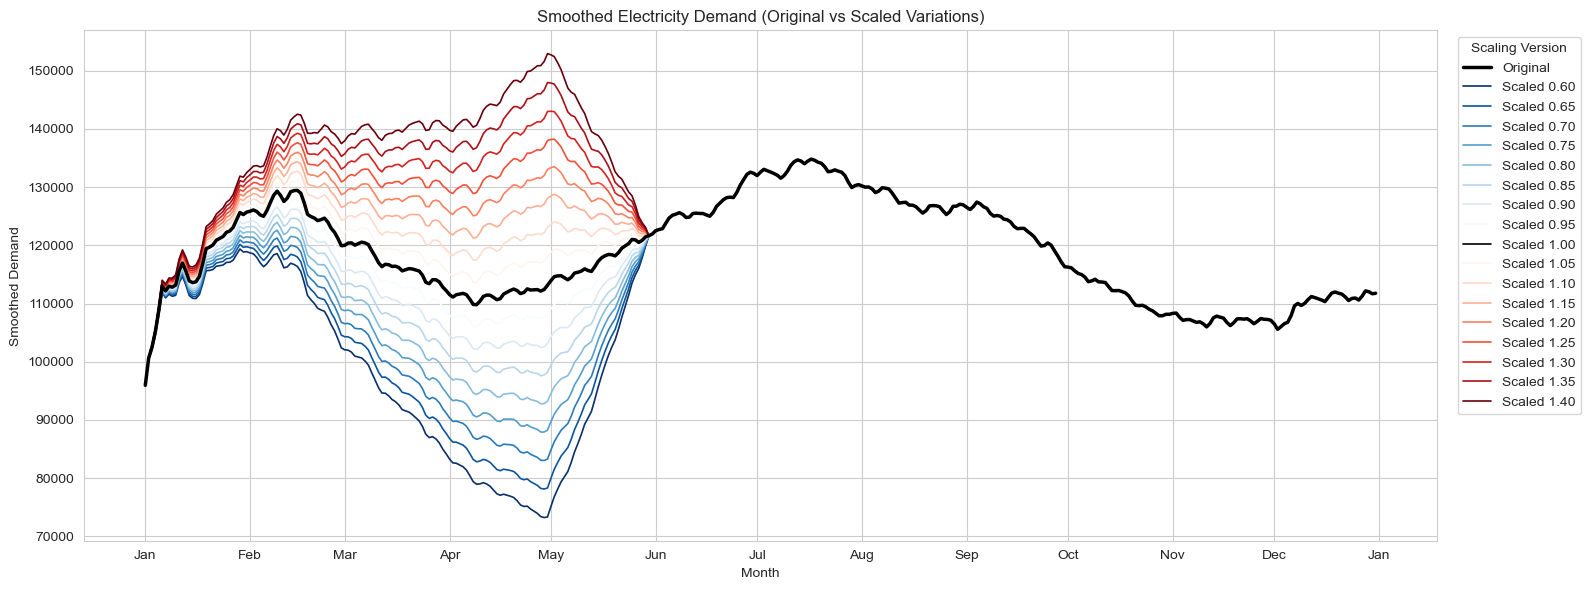

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import matplotlib

# Load the data
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])

# Extract date components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Filter and sort
df = df[df['year'] == 2018].sort_values(['year', 'date'])

# Define drift period (example: P1)
periods = [
    ("2018-01-01", "2018-04-30", "P1"),
    ("2018-05-01", "2018-08-31", "P2"),
    ("2018-09-01", "2018-12-31", "P3"),
]
(start, end, period_id) = periods[0]

# Create base DataFrame for plotting
plot_dfs = []

# Add original (unscaled) smoothed demand
df['demand_smooth'] = df.groupby('year')['demand'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
original = df[['date', 'year', 'demand_smooth']].copy()
original['version'] = 'Original'
plot_dfs.append(original)

# Scaling levels from 0.6 to 1.4 (step 0.05)
scaling_levels = np.round(np.arange(0.6, 1.41, 0.05), 2)

for scale in scaling_levels:
    df_scaled = df.copy()
    mask = (
        (df_scaled['date'] >= pd.to_datetime(start)) &
        (df_scaled['date'] <= pd.to_datetime(end)) &
        (df_scaled['date'].dt.year == 2018)
    )
    n = mask.sum()
    if n > 0:
        # Sinusoidal ramp scaling
        scaling_factors = np.linspace(1.0, scale, n)
        df_scaled.loc[mask, 'demand'] *= scaling_factors

    # Smooth the scaled data
    df_scaled['demand_smooth'] = df_scaled.groupby('year')['demand'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

    df_temp = df_scaled[['date', 'year', 'demand_smooth']].copy()
    df_temp['version'] = f'Scaled {scale:.2f}'
    plot_dfs.append(df_temp)

# Concatenate all versions
df_plot = pd.concat(plot_dfs, ignore_index=True)

# --- Plot ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Prepare color maps ---
red_cmap = matplotlib.colormaps['Reds']
blue_cmap = matplotlib.colormaps['Blues_r']

# Get list of unique scaling values (excluding original)
scale_values = sorted([v for v in df_plot['version'].unique() if v != 'Original'])

# Separate into >1 and <1
scale_high = sorted([s for s in scale_values if float(s.split()[1]) > 1])
scale_low = sorted([s for s in scale_values if float(s.split()[1]) < 1])

# Normalize for color mapping
norm_high = mcolors.Normalize(vmin=1.05, vmax=1.4)
norm_low = mcolors.Normalize(vmin=0.6, vmax=0.95)

# Create a color dictionary
color_dict = {
     'Scaled 1.00': 'black',
    'Original': 'black'
}
for s in scale_high:
    val = float(s.split()[1])
    color_dict[s] = red_cmap(norm_high(val))
for s in scale_low:
    val = float(s.split()[1])
    color_dict[s] = blue_cmap(norm_low(val))

# --- Plot ---
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

for version in df_plot['version'].unique():
    df_sub = df_plot[df_plot['version'] == version]
    is_original = version == 'Original'
    lw = 2.5 if is_original else 1.2
    z = 3 if is_original else 1  # higher zorder for original

    plt.plot(
        df_sub['date'],
        df_sub['demand_smooth'],
        label=version,
        color=color_dict[version],
        linewidth=lw,
        zorder=z
    )


# Format x-axis to show months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.title('Smoothed Electricity Demand (Original vs Scaled Variations)')
plt.xlabel('Month')
plt.ylabel('Smoothed Demand')
plt.legend(title='Scaling Version', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [44]:
grouped.mean()

date
2015-01-01     99635.030000
2015-01-02    114620.520000
2015-01-03    123847.193333
2015-01-04    118968.073750
2015-01-05    118800.899000
                  ...      
2019-12-27    109312.282167
2019-12-28    109338.475833
2019-12-29    109454.929667
2019-12-30    110836.615167
2019-12-31    110675.828833
Name: demand_smooth, Length: 1826, dtype: float64

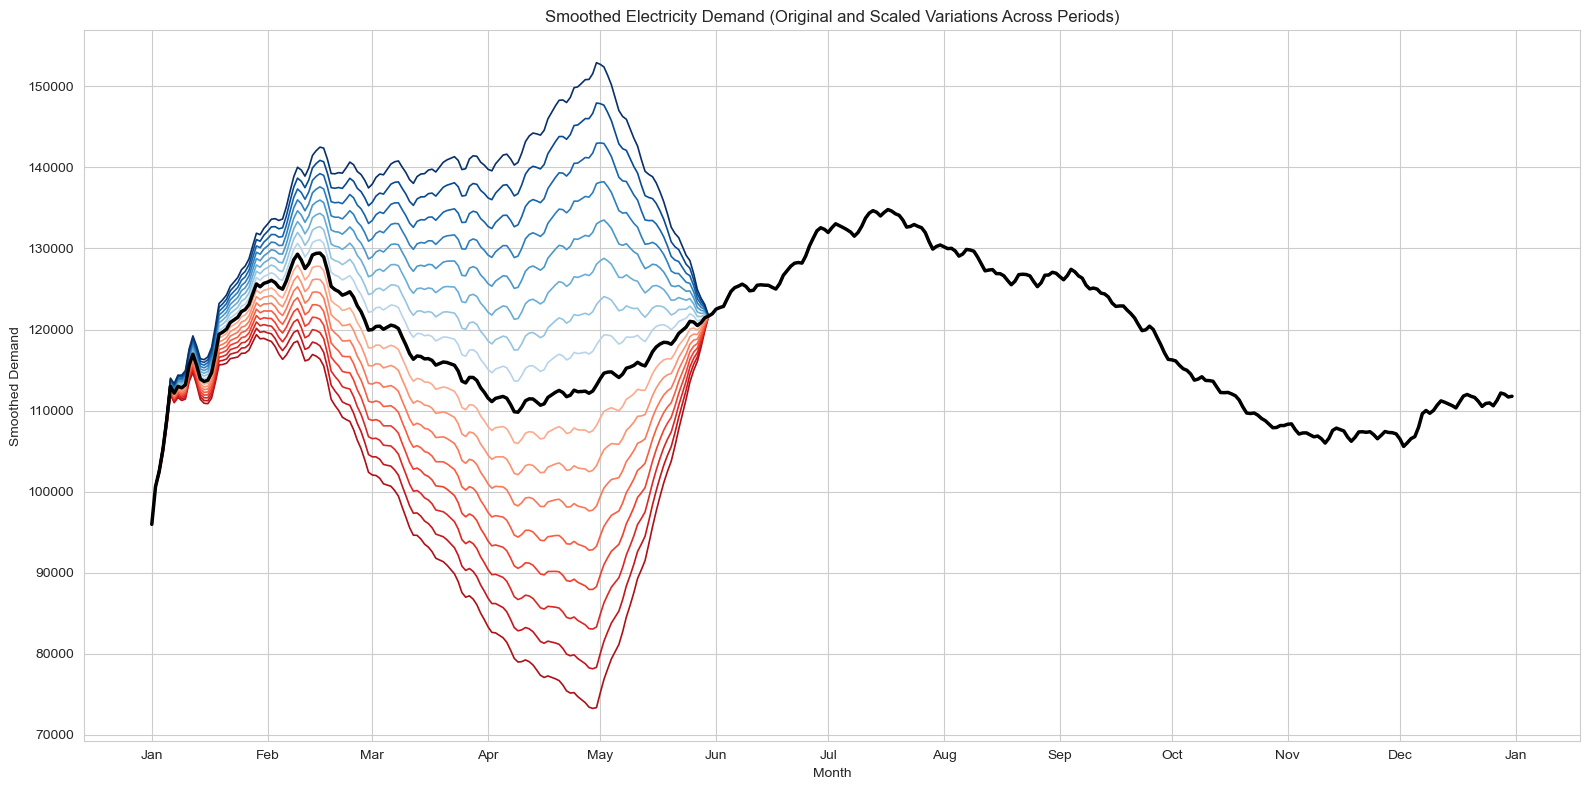

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import matplotlib
import scipy.stats as stats


# Load the data
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])

# Extract date components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month


# 1. Filter data to exclude 2020 and group by date
df_others = df[df['year'] != 2020].copy()

# Smooth demand for those years if not already done:
df_others['demand_smooth'] = df_others.groupby('year')['demand'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# Group by date to get mean and CI
grouped = df_others.groupby('date')['demand_smooth']

mean_demand = grouped.mean()
sem = grouped.sem()  # standard error of mean
ci95 = sem * stats.t.ppf((1 + 0.95) / 2, grouped.count() - 1)

# Prepare dataframe for plotting
ci_df = pd.DataFrame({
    'date': mean_demand.index,
    'mean': mean_demand.values,
    'lower': mean_demand.values - ci95,
    'upper': mean_demand.values + ci95
})



# Filter and sort
df = df[df['year'] == 2018].sort_values(['year', 'date'])

periods = [
    ("2018-01-01", "2018-04-30", "P1"),
    # ("2018-05-01", "2018-08-31", "P2"),
    # ("2018-09-01", "2018-12-31", "P3"),
]

plot_dfs = []

# Add original (unscaled) smoothed demand for full 2018
df['demand_smooth'] = df.groupby('year')['demand'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
original = df[['date', 'year', 'demand_smooth']].copy()
original['version'] = 'Original'
original['period_id'] = 'None'  # or 'Original' to mark no period scaling
plot_dfs.append(original)

# Scaling levels from 0.6 to 1.4 (step 0.05)
scaling_levels = np.round(np.arange(0.6, 1.41, 0.05), 2)

for (start, end, period_id) in periods:
    for scale in scaling_levels:
        df_scaled = df.copy()
        mask = (
            (df_scaled['date'] >= pd.to_datetime(start)) &
            (df_scaled['date'] <= pd.to_datetime(end))
        )
        n = mask.sum()
        if n > 0:
            scaling_factors = np.linspace(1.0, scale, n)
            df_scaled.loc[mask, 'demand'] *= scaling_factors

        # Smooth the scaled data
        df_scaled['demand_smooth'] = df_scaled.groupby('year')['demand'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

        df_temp = df_scaled[['date', 'year', 'demand_smooth']].copy()
        df_temp['version'] = f'{period_id} Scaled {scale:.2f}'
        df_temp['period_id'] = period_id
        plot_dfs.append(df_temp)

# Concatenate all
df_plot = pd.concat(plot_dfs, ignore_index=True)

# --- Prepare colors (same as before) ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# Define a new colormap function that starts from 0.2 (skip first 20%) to 1.0 (end)
def truncated_cmap(cmap, min_val=0.2, max_val=1.0, n=256):
    colors = cmap(np.linspace(min_val, max_val, n))
    return matplotlib.colors.LinearSegmentedColormap.from_list(f'trunc({cmap.name},{min_val:.2f},{max_val:.2f})', colors)

blue_cmap = truncated_cmap(matplotlib.colormaps['Blues'], min_val=0.3, max_val=1.0)
red_cmap = truncated_cmap(matplotlib.colormaps['Reds_r'], min_val=0.15, max_val=0.7)



scale_values = sorted([v for v in df_plot['version'].unique() if 'Scaled' in v])
scale_high = sorted([s for s in scale_values if float(s.split()[-1]) > 1])
scale_low = sorted([s for s in scale_values if float(s.split()[-1]) < 1])

norm_high = mcolors.Normalize(vmin=1.05, vmax=1.4)
norm_low = mcolors.Normalize(vmin=0.6, vmax=0.95)

color_dict = {
    'Original': 'black'
}
for s in scale_high:
    val = float(s.split()[-1])
    color_dict[s] = blue_cmap(norm_high(val))
for s in scale_low:
    val = float(s.split()[-1])
    color_dict[s] = red_cmap(norm_low(val))

# --- Plot ---
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

for version in df_plot['version'].unique():
    df_sub = df_plot[df_plot['version'] == version]
    is_original = version == 'Original'
    lw = 2.5 if is_original else 1.2
    z = 3 if is_original else 1

    plt.plot(
        df_sub['date'],
        df_sub['demand_smooth'],
        label=version,
        color=color_dict.get(version, 'gray'),
        linewidth=lw,
        zorder=z
    )

# Format x-axis to show months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.title('Smoothed Electricity Demand (Original and Scaled Variations Across Periods)')
plt.xlabel('Month')
plt.ylabel('Smoothed Demand')
# plt.legend(title='Version', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])
df

,date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
0,2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,N,Y
1,2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,N,N
2,2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,N,N
3,2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,N,N
4,2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,2020-10-02,99585.835,-6.076028,41988.240,26.980251,57597.595,-30.173823,0.625000,12.8,26.0,22.0,0.0,N,N
2102,2020-10-03,92277.025,-1.983471,44133.510,32.438156,48143.515,-33.538025,0.583333,17.4,29.4,19.8,0.0,N,N
2103,2020-10-04,94081.565,25.008614,88580.995,26.571687,5500.570,-0.163066,0.062500,13.5,29.5,8.4,0.0,N,N
2104,2020-10-05,113610.030,36.764701,106587.375,39.616015,7022.655,-6.511550,0.083333,9.1,12.7,7.3,12.8,N,N


In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import matplotlib
import scipy.stats as stats
import datetime

# --- Prepare colors (same as before) ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

def plot_variations(periods, rolling_factor = 3):

    # Load the data
    df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])

    # Extract date components
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['month_day'] = df['date'].dt.strftime('%m-%d')
    df = df[df['year'] != 2020].copy()
    df['demand_smooth'] = df.groupby('year')['demand'].transform(lambda x: x.rolling(window=rolling_factor, min_periods=1).mean())

    df_others = df[df['year'] != 2018].copy()
    # Group by month_day across all years except 2020
    grouped_md = df_others.groupby('month_day')['demand_smooth']

    mean_demand_md = grouped_md.mean()
    sem_md = grouped_md.sem()
    count_md = grouped_md.count()
    ci95_md = sem_md * stats.t.ppf((1 + 0.95) / 2, count_md - 1)

    # Create a date range for 2018 (non-leap year)
    date_2018 = pd.date_range(start='2018-01-01', end='2018-12-31')

    # Map month_day strings to dates in 2018 for plotting x-axis
    md_to_date = {dt.strftime('%m-%d'): dt for dt in date_2018}

    # Prepare DataFrame for plotting CI and mean with correct x-axis dates
    ci_df = pd.DataFrame({
        'month_day': mean_demand_md.index,
        'mean': mean_demand_md.values,
        'lower': mean_demand_md.values - ci95_md,
        'upper': mean_demand_md.values + ci95_md
    })

    # Add corresponding 2018 date for plotting
    ci_df['date'] = ci_df['month_day'].map(md_to_date)

    # Sort by date to ensure correct order
    ci_df = ci_df.sort_values('date')


    # Filter and sort
    df = df[df['year'] == 2018].sort_values(['year', 'date'])

    plot_dfs = []

    # Add original (unscaled) smoothed demand for full 2018
    df['demand_smooth'] = df.groupby('year')['demand'].transform(lambda x: x.rolling(window=rolling_factor, min_periods=1).mean())
    original = df[['date', 'year', 'demand_smooth']].copy()
    original['version'] = 'Original'
    original['period_id'] = 'None'  # or 'Original' to mark no period scaling
    plot_dfs.append(original)

    # Scaling levels from 0.6 to 1.4 (step 0.05)
    scaling_levels = np.round(np.arange(0.6, 1.41, 0.05), 2)

    for (start, end, period_id) in periods:
        for scale in scaling_levels:
            df_scaled = df.copy()
            mask = (
                (df_scaled['date'] >= pd.to_datetime(start)) &
                (df_scaled['date'] <= pd.to_datetime(end))
            )
            n = mask.sum()
            if n > 0:
                scaling_factors = np.linspace(1.0, scale, n)
                df_scaled.loc[mask, 'demand'] *= scaling_factors

            # Smooth the scaled data
            df_scaled['demand_smooth'] = df_scaled.groupby('year')['demand'].transform(lambda x: x.rolling(window=rolling_factor, min_periods=1).mean())

            df_temp = df_scaled[['date', 'year', 'demand_smooth']].copy()
            df_temp['version'] = f'{period_id} Scaled {scale:.2f}'
            df_temp['period_id'] = period_id
            plot_dfs.append(df_temp)

    # Concatenate all
    df_plot = pd.concat(plot_dfs, ignore_index=True)



    # Define a new colormap function that starts from 0.2 (skip first 20%) to 1.0 (end)
    def truncated_cmap(cmap, min_val=0.2, max_val=1.0, n=256):
        colors = cmap(np.linspace(min_val, max_val, n))
        return matplotlib.colors.LinearSegmentedColormap.from_list(f'trunc({cmap.name},{min_val:.2f},{max_val:.2f})', colors)

    blue_cmap = truncated_cmap(matplotlib.colormaps['Blues'], min_val=0.3, max_val=1.0)
    red_cmap = truncated_cmap(matplotlib.colormaps['Reds_r'], min_val=0.15, max_val=0.7)



    scale_values = sorted([v for v in df_plot['version'].unique() if 'Scaled' in v])
    scale_high = sorted([s for s in scale_values if float(s.split()[-1]) > 1])
    scale_low = sorted([s for s in scale_values if float(s.split()[-1]) < 1])

    norm_high = mcolors.Normalize(vmin=1.05, vmax=1.4)
    norm_low = mcolors.Normalize(vmin=0.6, vmax=0.95)

    color_dict = {
        'Original': 'black'
    }
    for s in scale_high:
        val = float(s.split()[-1])
        color_dict[s] = blue_cmap(norm_high(val))
    for s in scale_low:
        val = float(s.split()[-1])
        color_dict[s] = red_cmap(norm_low(val))

    # --- Plot ---
    plt.figure(figsize=(16, 8))
    sns.set_style("whitegrid")

    for version in df_plot['version'].unique():
        # df_sub = df_plot[df_plot['version'] == version]
        # is_original = version == 'Original'
        # lw = 2 if is_original else 1.2
        # z = 3 if is_original else 1
        #
        #
        # plt.plot(
        #     df_sub['date'],
        #     df_sub['demand_smooth'],
        #     label=version,
        #     color=color_dict.get(version, 'gray'),
        #     linewidth=lw,
        #     zorder=z
        # )

        df_sub = df_plot[df_plot['version'] == version]
        is_original = version == 'Original'
        lw = 2 if is_original else 1.2
        z = 3 if is_original else 1

        if is_original:
            # Plot full original line
            plt.plot(
                df_sub['date'],
                df_sub['demand_smooth'],
                label=version,
                color=color_dict.get(version, 'black'),
                linewidth=lw,
                zorder=z
            )
        else:
            # Highlight P2 only
            df_sub_high = df_sub[df_sub['period_id'] == 'P2']
            plt.plot(
                df_sub_high['date'],
                df_sub_high['demand_smooth'],
                label=version,
                color=color_dict.get(version, 'gray'),
                linewidth=lw,
                zorder=z
            )

            # Optional: show faded gray for non-P2 periods
            df_sub_low = df_sub[df_sub['period_id'] != 'P2']
            plt.plot(
                df_sub_low['date'],
                df_sub_low['demand_smooth'],
                color='gray',
                linewidth=0.75,
                zorder=0
            )

    plt.fill_between(ci_df['date'], ci_df['lower'], ci_df['upper'], color='violet', alpha=0.3,zorder=2, label='95% CI (others)')
    plt.plot(ci_df['date'], ci_df['mean'], color='purple', linewidth=3, zorder=2, label='Mean (others)')

    # # And set the x-axis limits same as before:
    # plt.xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2018-12-31'))

    # Format x-axis to show months
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    plt.title('Smoothed Electricity Demand (Original and Scaled Variations Across Periods)')
    plt.xlabel('Month')
    plt.ylabel('Smoothed Demand')
    # plt.legend(title='Version', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()

    return df_plot


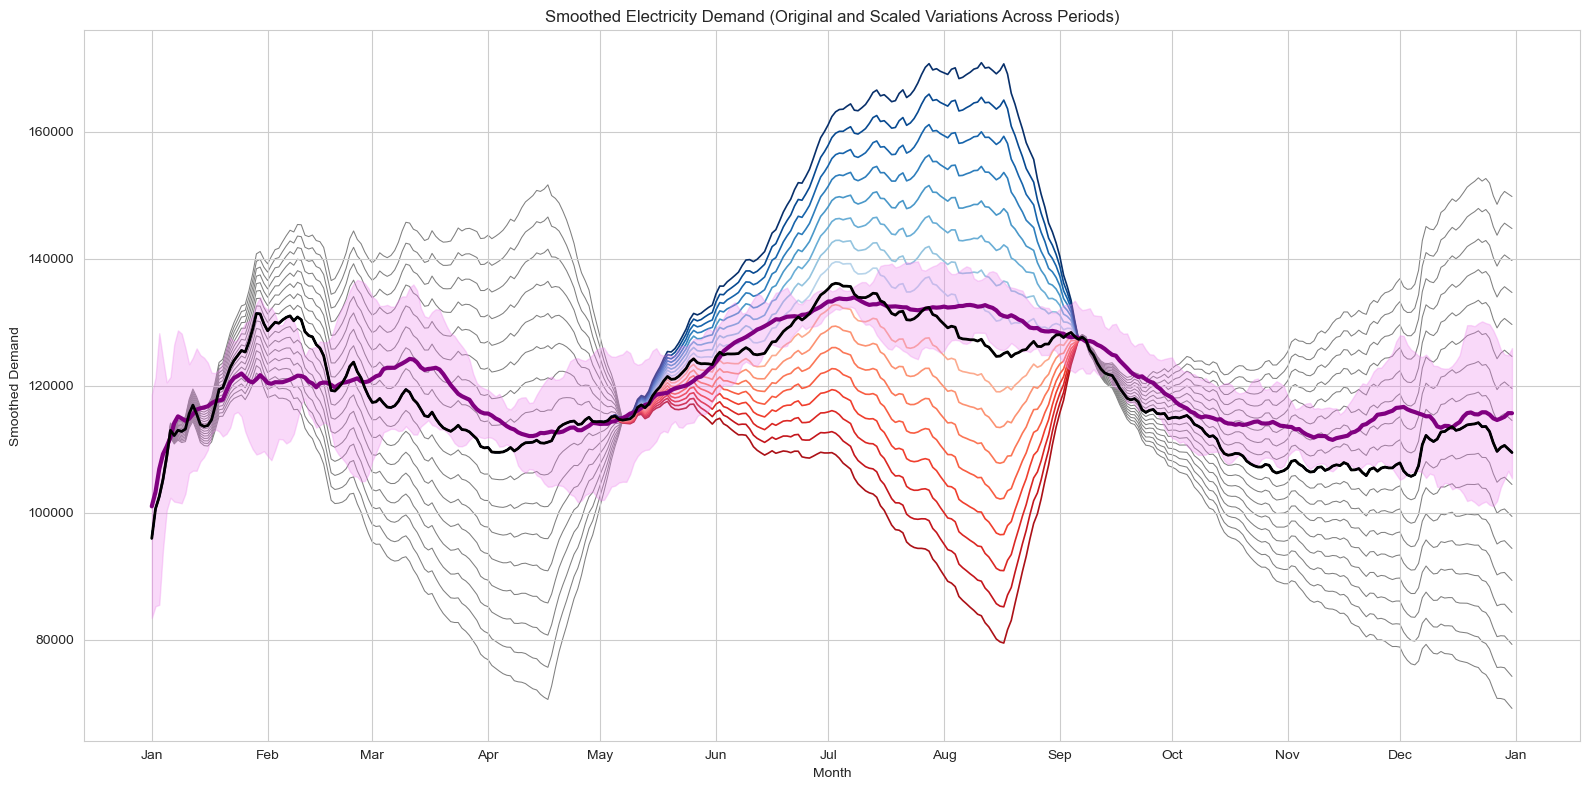

In [152]:
periods = [
    ("2018-01-01", "2018-04-17", "P1"),
    ("2018-05-01", "2018-08-17", "P2"),
    ("2018-09-01", "2018-12-31", "P3"),
]

zxc = plot_variations(periods, rolling_factor = 20)

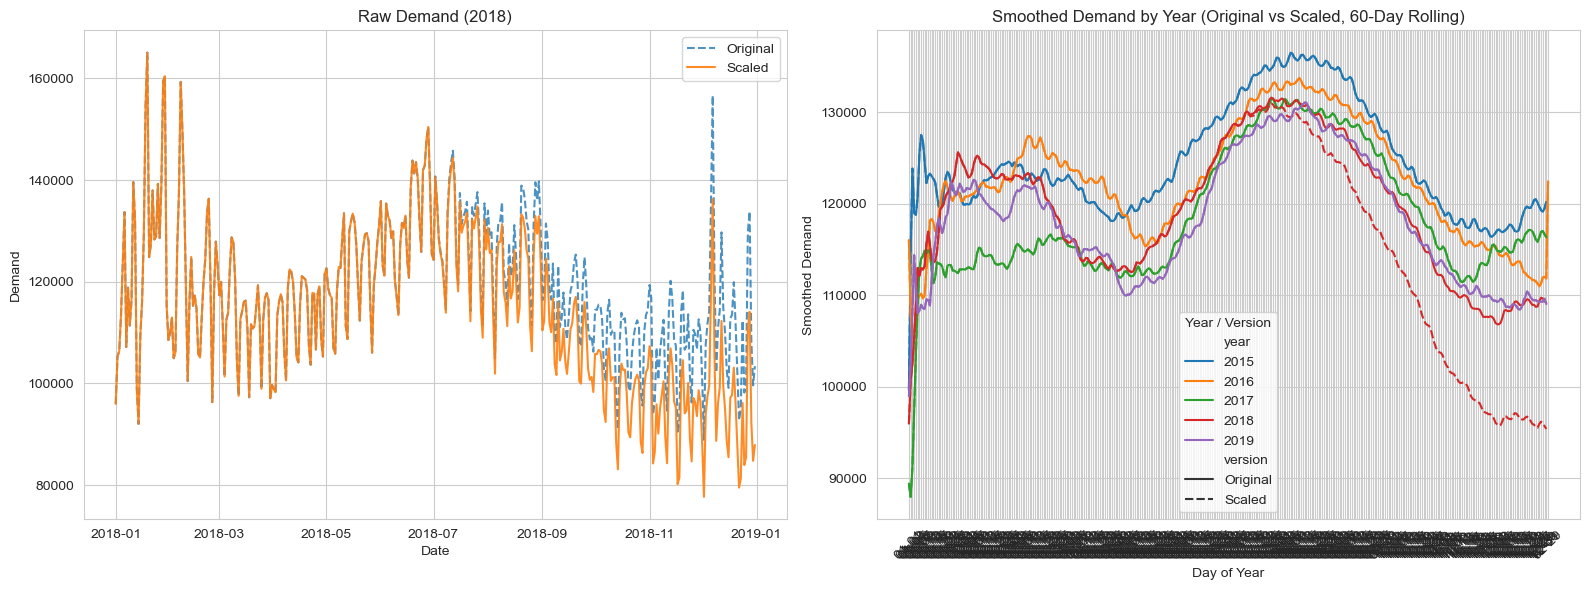

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def apply_smooth_scaling(df, start_date, end_date, scaling_factor=0.85, window=60, figsize=(16, 6)):
    """
    Applies smooth linear scaling to demand in a defined period and plots raw + smoothed results.

    Parameters:
        df (pd.DataFrame): DataFrame with 'date' and 'demand' columns.
        start_date (str or pd.Timestamp): Start of scaling period.
        end_date (str or pd.Timestamp): End of scaling period.
        scaling_factor (float): Final value to scale down to.
        window (int): Rolling average window.
        figsize (tuple or None): If not None, shows plots with raw and smoothed series.

    Returns:
        pd.DataFrame: DataFrame with added columns:
            - 'demand_scaled'
            - 'demand_smooth_original'
            - 'demand_smooth_scaled'
    """
    df = df.copy()

    # Ensure proper datetime parsing
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month_day'] = df['date'].dt.strftime('%m-%d')
    df['month'] = df['date'].dt.month

    # Sort and filter
    df = df.sort_values(['year', 'date'])
    df = df[df['year'] != 2020]

    # Add scaled demand column
    df['demand_scaled'] = df['demand']

    # Define scaling window
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    mask = (df['date'] >= start_date) & (df['date'] <= end_date)
    transition_dates = df.loc[mask, 'date']
    n = len(transition_dates)

    if n == 0:
        raise ValueError("No dates matched the scaling window. Check start_date, end_date, and year == 2018.")

    # Linear scaling factors
    scaling_factors = np.linspace(1.0, scaling_factor, n)

    # Apply smooth scaling
    df.loc[mask, 'demand_scaled'] = df.loc[mask, 'demand'].values * scaling_factors

    # Smooth both versions
    df['demand_smooth_original'] = df.groupby('year')['demand'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df['demand_smooth_scaled'] = df.groupby('year')['demand_scaled'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

    if figsize:
        sns.set_style("whitegrid")

        # --- Left plot: Raw demand 2017 ---
        plt.figure(figsize=figsize)
        plt.subplot(1, 2, 1)
        plt.plot(df.loc[df['year'] == 2018, 'date'], df.loc[df['year'] == 2018, 'demand'], label='Original', linestyle='--', alpha=0.8)
        plt.plot(df.loc[df['year'] == 2018, 'date'], df.loc[df['year'] == 2018, 'demand_scaled'], label='Scaled', alpha=0.9)
        plt.title('Raw Demand (2018)')
        plt.xlabel('Date')
        plt.ylabel('Demand')
        plt.legend()

        # --- Right plot: Smoothed multi-year lineplot ---
        plt.subplot(1, 2, 2)

        # Prepare data for seaborn plot (like before)
        df_plot = pd.melt(
            df,
            id_vars=['date', 'year', 'month_day'],
            value_vars=['demand_smooth_original', 'demand_smooth_scaled'],
            var_name='version',
            value_name='demand_smooth'
        )

        df_plot['version'] = df_plot['version'].map({
            'demand_smooth_original': 'Original',
            'demand_smooth_scaled': 'Scaled'
        })

        df_plot = df_plot.groupby(['version', 'year', 'month_day'], as_index=False)['demand_smooth'].mean()

        sns.lineplot(
            data=df_plot,
            x='month_day',
            y='demand_smooth',
            hue='year',
            style='version',
            palette='tab10'
        )
        plt.title(f'Smoothed Demand by Year (Original vs Scaled, {window}-Day Rolling)')
        plt.xlabel('Day of Year')
        plt.ylabel('Smoothed Demand')
        plt.xticks(rotation=45)
        plt.legend(title='Year / Version')
        plt.tight_layout()
        plt.show()

    return df



df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])

# Call the function
df_result = apply_smooth_scaling(
    df,
    start_date='2018-07-01',
    end_date='2018-12-31',
    scaling_factor=0.85,
    window=60,
    figsize=(16, 6)
)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

def rank_features_full(
    df,
    target='demand',
    features=None,
    n_bins=10,
    random_state=42,
    rfe_estimator=None,
    rfe_step=1,
    rfe_cv=5,
):
    """
    Rank features by multiple informativeness metrics related to `target`:
    - Mutual Information (MI)
    - Absolute Pearson Correlation
    - Random Forest Feature Importance
    - Recursive Feature Elimination (RFE) importance ranking

    Parameters:
        df (pd.DataFrame): DataFrame with target and features
        target (str): name of target variable
        features (list or None): list of features (if None uses all except target & date)
        n_bins (int): bins for discretizing (unused here but placeholder)
        random_state (int): random seed for reproducibility
        rfe_estimator: sklearn estimator for RFE (default LinearRegression)
        rfe_step (int): number of features to remove per RFE iteration
        rfe_cv (int): folds for cross-validation (not used here but can be extended)

    Returns:
        pd.DataFrame: feature rankings sorted by combined average rank (ascending)
    """
    if features is None:
        features = df.columns.drop([target, 'date'])

    X = df[features].copy()
    y = df[target].values

    # Fill NaNs with 0 for simplicity (can use other imputation)
    X_filled = X.fillna(0)

    # --- Mutual Information ---
    mi = mutual_info_regression(X_filled, y, random_state=random_state)

    # --- Correlation ---
    corr = X.corrwith(df[target]).abs()

    # --- Random Forest Feature Importance ---
    X_train, X_test, y_train, y_test = train_test_split(X_filled, y, random_state=random_state)
    rf = RandomForestRegressor(random_state=random_state, n_estimators=100)
    rf.fit(X_train, y_train)
    rf_importances = rf.feature_importances_

    # --- Recursive Feature Elimination (RFE) ---
    if rfe_estimator is None:
        rfe_estimator = LinearRegression()
    rfe = RFE(estimator=rfe_estimator, step=rfe_step)
    rfe.fit(X_filled, y)
    # RFE ranking: lower rank is more important, invert it for importance score
    max_rank = rfe.ranking_.max()
    rfe_importances = max_rank - rfe.ranking_ + 1  # Higher is better

    # Assemble results
    results = pd.DataFrame({
        'feature': features,
        'mutual_info': mi,
        'abs_correlation': corr,
        'rf_importance': rf_importances,
        'rfe_importance': rfe_importances
    })

    # Normalize columns for ranking comparability (0 to 1 scale)
    for col in ['mutual_info', 'abs_correlation', 'rf_importance', 'rfe_importance']:
        min_val = results[col].min()
        max_val = results[col].max()
        if max_val - min_val > 0:
            results[col + '_norm'] = (results[col] - min_val) / (max_val - min_val)
        else:
            results[col + '_norm'] = 0

    # Compute average rank (ascending uninformative → informative)
    # So we rank each metric ascending (lowest first), then average ranks
    norm_cols = [col + '_norm' for col in ['mutual_info', 'abs_correlation', 'rf_importance', 'rfe_importance']]
    results['average_norm'] = results[norm_cols].mean(axis=1)

    # Sort by average_norm ascending (least informative at top)
    results = results.sort_values('average_norm').reset_index(drop=True)

    return results

In [ ]:
features = ['RRP', 'demand_pos_RRP', 'demand_neg_RRP',
            'frac_at_neg_RRP', 'min_temperature', 'max_temperature', 'solar_exposure', 'rainfall']

rankings = rank_features_full(df, target='demand', features=features)
rankings[['feature', 'mutual_info', 'abs_correlation', 'rf_importance', 'rfe_importance', 'average_norm']]

In [ ]:
for tgt_var in rankings['feature'].tolist():
    data_plot = df.copy()

    data_plot['year'] = data_plot['date'].dt.year
    data_plot['month_day'] = data_plot['date'].dt.strftime('%m-%d')
    data_plot['month'] = data_plot['date'].dt.month

    # Sort for proper rolling
    data_plot = data_plot.sort_values(['year', 'date'])
    data_plot = data_plot[data_plot['year'] != 2020]


    # Group by year and apply 7-day rolling average to demand
    data_plot['demand_smooth'] = data_plot.groupby('year')[tgt_var].transform(lambda x: x.rolling(window=60, min_periods=1).mean())

    # Now we want to aggregate by month_day for plotting (after smoothing)
    data_plot_smooth = data_plot.groupby(['year', 'month_day'], as_index=False)['demand_smooth'].mean()

    # Plot
    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")

    sns.lineplot(data=data_plot_smooth, x='month_day', y='demand_smooth', hue='year', palette='tab10')

    plt.title(f'Smoothed{tgt_var} by Year (7-Day Rolling Mean)')
    plt.xlabel('Day of Year')
    plt.ylabel('Smoothed Demand')
    plt.xticks(rotation=45)
    plt.legend(title='Year')
    plt.tight_layout()
    plt.show()

In [ ]:
df.head()

In [ ]:
import os
import string

# Suppose `results` is the ranking DataFrame from rank_features_full,
# sorted ascending by informativeness (least informative first)

# Get the first 5 least informative features in order:
uninformative_features = ['solar_exposure', 'min_temperature', 'max_temperature',  'rainfall', 'RRP']

# Output directory
output_dir = 'data_leaks/benchmark/energy'
os.makedirs(output_dir, exist_ok=True)

# Sorted unique years
years = sorted(df['date'].dt.year.unique())

for i, year in enumerate(years):
    # Filter data for the year
    df_year = df[df['date'].dt.year == year].copy()

    # Base columns always included
    base_cols = ['date', 'demand']

    # Add progressively more uninformative features, from 1 to 5
    for num_feats in range(1, len(uninformative_features) + 1):
        # Columns to include: base + first num_feats uninformative features
        selected_features = base_cols + uninformative_features[:num_feats]

        # Select and copy relevant columns if exist in df_year
        available_features = [f for f in selected_features if f in df_year.columns]
        df_subset = df_year[available_features].copy()

        # Create timestamp column for this subset
        df_subset = df_subset.sort_values('date')
        df_subset['timestamp'] = (df_subset['date'] - df_subset['date'].min()).dt.total_seconds().astype(int)

        # Drop original date column
        df_subset = df_subset.drop(columns=['date'])

        # Fill missing values forward
        df_subset.ffill(inplace=True)


        # Optionally limit to first 365 rows if needed
        df_subset = df_subset.iloc[:365, :]

        # Determine filename, e.g. ClientA_1feats.csv, ClientA_2feats.csv, etc.
        client_id = string.ascii_uppercase[i]  # 'A', 'B', 'C', ...
        file_name = f'Client{client_id}_{num_feats}feats.csv'
        file_path = os.path.join(output_dir, file_name)

        # Save CSV
        df_subset.to_csv(file_path, index=False)

        print(f"Saved {year}-{file_name} with columns: {list(df_subset.columns)}")

In [ ]:
df.head()

In [ ]:
import pandas as pd
import numpy as np
import os
import string
from datetime import datetime

# Load the data
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])

# Dummy rankings for uninformative features (replace with actual ranking logic if needed)
# Simulating that these are the least informative - rankings['feature'].head(5).tolist()
uninformative_features = ['demand_pos_RRP', 'solar_exposure', 'min_temperature', 'max_temperature',  'rainfall', 'RRP']

# Ensure output directory exists
output_dir = 'data_leaks/benchmark/energy'
os.makedirs(output_dir, exist_ok=True)

# Define 3 periods for 2017
periods = [
    ("2018-01-01", "2018-04-30", "R1"),
    ("2018-05-01", "2018-08-31", "R2"),
    ("2018-09-01", "2018-12-31", "R3"),
]

# Define scaling factors with short IDs
scaling_levels = [
    (1.40, 's+40'), (1.30, 's+30'), (1.15, 's+15'),
    (0.60, 's-40'), (0.70, 's-30'), (0.85, 's-15')
]

# Filter out 2020 and sort
df = df[df['date'].dt.year != 2020].sort_values('date')

# Apply concept drift and add uninformative features
for (start, end, period_id) in periods:
    for (scale, scale_id) in scaling_levels:

        if (scale_id == 's100') and (period_id != 'P1'):
            continue

        df_copy = df.copy()

        # Apply smooth scaling to 'demand' for this period in 2018
        mask = (
            (df_copy['date'] >= pd.to_datetime(start)) &
            (df_copy['date'] <= pd.to_datetime(end)) &
            (df_copy['date'].dt.year == 2018)
        )
        n = mask.sum()
        if n > 0:
            # scaling_factors = np.linspace(1.0, scale, n)
            x = np.linspace(0, np.pi, n)
            scaling_factors = 1 + (scale - 1) * np.sin(x)**2  # smooth ramp up and down

            scaling_factors = np.linspace(1.0, scale, n)
            df_copy.loc[mask, 'demand'] *= scaling_factors

        # For each year create 5 versions with increasing uninformative features
        for i, year in enumerate(sorted(df_copy['date'].dt.year.unique())):
            df_year = df_copy[df_copy['date'].dt.year == year].copy()

            for num_feats in range(1, len(uninformative_features) + 1):
                # Base + n uninformative features
                base_cols = ['date', 'demand']
                selected = base_cols + uninformative_features[:num_feats]
                available = [col for col in selected if col in df_year.columns]

                df_subset = df_year[available].copy()
                df_subset = df_subset.sort_values('date')
                df_subset['timestamp'] = (df_subset['date'] - df_subset['date'].min()).dt.total_seconds().astype(int)
                df_subset = df_subset.drop(columns=['date'])
                df_subset.ffill(inplace=True)
                df_subset = df_subset.iloc[:365, :]

                # Save file
                file_dir = output_dir + f'/{period_id}_{scale_id}_{num_feats}feats'
                os.makedirs(file_dir, exist_ok=True)


                client_id = string.ascii_uppercase[i]
                filename = f"Client{client_id}.csv"
                path = os.path.join(file_dir, filename)
                df_subset = df_subset[['timestamp', 'demand'] + uninformative_features[:num_feats]]
                df_subset.to_csv(path, index=False)

print("✅ Drifted and augmented files saved successfully.")

In [33]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_demand_by_config(
    period_id="P1",
    scale_id="s100",
    num_feats=1,
    data_root="data_leaks/benchmark/energy",
    smooth=False,
    window=30,
    figsize=(14, 6)
):
    """
    Plot demand for each client for a specific (period, scale, num_feats) config.

    Parameters
    ----------
    period_id : {"P1","P2","P3"}
        Drifted period identifier.
    scale_id  : str
        Scaling level identifier (e.g., "s+10", "s100", "s-10").
    num_feats : int
        Number of uninformative features (1–5).
    data_root : str
        Root directory where all client subfolders are saved.
    smooth    : bool
        Whether to apply centered rolling average to demand.
    window    : int
        Window size for smoothing.
    figsize   : tuple
        Size of the plot.

    Returns
    -------
    None
    """

    # ------------------------------------------------------------------
    # 1. Locate the target folder
    # ------------------------------------------------------------------
    subdir = f"{period_id}_{scale_id}_{num_feats}feats"
    target_dir = os.path.join(data_root, subdir)

    if not os.path.isdir(target_dir):
        print(f"Directory '{target_dir}' not found.")
        return

    # ------------------------------------------------------------------
    # 2. Collect all client CSVs in that folder
    # ------------------------------------------------------------------
    pattern = re.compile(r"Client([A-Z])\.csv$", re.I)
    files = [
        f for f in os.listdir(target_dir)
        if pattern.match(f)
    ]
    if not files:
        print(f"No client files found in '{target_dir}'.")
        return

    # ------------------------------------------------------------------
    # 3. Read each client file and convert timestamp to datetime
    # ------------------------------------------------------------------
    client_data = []
    for fname in sorted(files):
        fpath = os.path.join(target_dir, fname)
        df_cli = pd.read_csv(fpath)

        # Convert timestamp (seconds) to datetime assuming base date Jan 1, 2018
        df_cli['date'] = pd.to_datetime('2018-01-01') + pd.to_timedelta(df_cli['timestamp'], unit='s')
        df_cli['client'] = pattern.match(fname).group(1)

        if smooth:
            df_cli['demand_plot'] = (
                df_cli['demand']
                .rolling(window=window, center=True, min_periods=1)
                .mean()
            )
        else:
            df_cli['demand_plot'] = df_cli['demand']

        client_data.append(df_cli[['date', 'demand_plot', 'client']])

    plot_df = pd.concat(client_data, ignore_index=True)

    # ------------------------------------------------------------------
    # 4. Plot
    # ------------------------------------------------------------------
    sns.set_style("whitegrid")
    plt.figure(figsize=figsize)

    sns.lineplot(
        data=plot_df,
        x="date",
        y="demand_plot",
        hue="client",
        palette="tab10"
    )

    # Set monthly locator and formatter for x-axis
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    title = (
        f"Demand – {period_id}, scale {scale_id}, {num_feats} uninformative feature"
        + ("s" if num_feats > 1 else "")
        + (" (smoothed)" if smooth else " (raw)")
    )
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Demand")
    plt.tight_layout()
    plt.show()


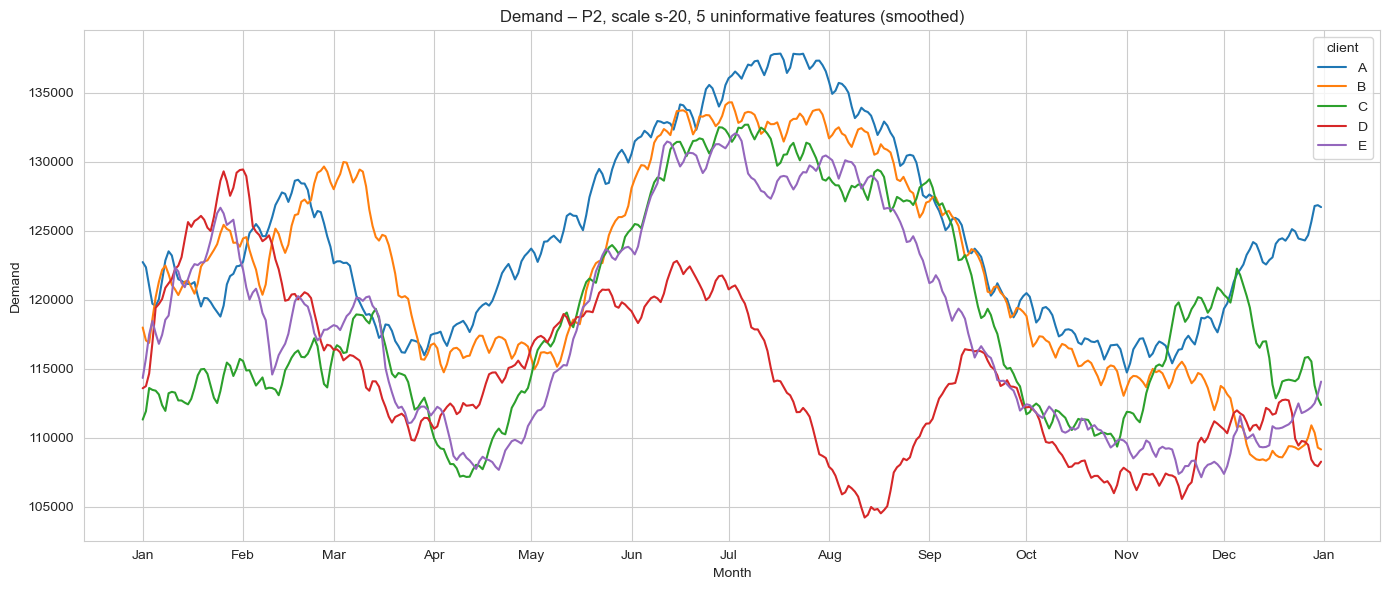

In [36]:
plot_demand_by_config(period_id="P2", scale_id="s-20", num_feats=5, smooth=True, window=30)

In [ ]:
import os
import glob

file_paths = glob.glob(f'datasets/benchmark/Benchmark_energy/P*')
file_paths[:5]

In [ ]:
exp_id = file_paths[0]

n_feats = int(exp_id[-6]) + 1
n_feats

In [ ]:
exp_id[-14:]

In [ ]:
import os
import glob

station_dfs = []
file_paths = glob.glob(f'data_leaks/benchmark/energy/*.csv')
for path in file_paths:
    df = pd.read_csv(path)
    id = path[-5:].replace('.csv', '')
    df['id'] = id
    station_dfs.append(df)

data = pd.concat(station_dfs)


client_map = ['A', 'B', 'C', 'D', 'E']

data_clients = {}
for id in client_map:
    data_clients[f"Client{id}"] = {}


    # Save to CSV
    file_name = f"Client{id}_Baseline.csv"
    data_clients[f"Client{id}"]['Baseline'] = data[data['id'] == id].drop(columns=['id'])

data_clients

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Load the CSV data
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])
# Extract year and normalized date part
df['year'] = df['date'].dt.year
df['month_day'] = df['date'].dt.strftime('%m-%d')
df['month'] = df['date'].dt.month

# Sort for proper rolling
df = df.sort_values(['year', 'date'])
df = df[df['year'] != 2020]

tgt_var = 'max_temperature'

# Apply scaling to the demand column
df.loc[mask, tgt_var] = df.loc[mask, tgt_var].values * scaling_factors


# Group by year and apply 7-day rolling average to demand
df['demand_smooth'] = df.groupby('year')[tgt_var].transform(lambda x: x.rolling(window=60, min_periods=1).mean())

# Now we want to aggregate by month_day for plotting (after smoothing)
df_smooth = df.groupby(['year', 'month_day'], as_index=False)['demand_smooth'].mean()

# Plot
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

sns.lineplot(data=df_smooth, x='month_day', y='demand_smooth', hue='year', palette='tab10')

plt.title('Smoothed Daily Electricity Demand by Year (7-Day Rolling Mean)')
plt.xlabel('Day of Year')
plt.ylabel('Smoothed Demand')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CSV data
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])
# Extract year and normalized date part
df['year'] = df['date'].dt.year
df['month_day'] = df['date'].dt.strftime('%m-%d')
df['month'] = df['date'].dt.month

# Sort for proper rolling
df = df.sort_values(['year', 'date'])
df = df[df['year'] != 2020]

# Drop non-numeric columns to compute correlation
numeric_df = df.select_dtypes(include='number')

# Compute correlations with demand
correlation_with_demand = numeric_df.corr()['demand'].sort_values(ascending=False)

# Display top correlations
print(correlation_with_demand)


In [ ]:
for i in list(range(0, 4)):
    print(i)

In [1]:
import pandas as pd
import os
import glob
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle

from sklearn.metrics.pairwise import cosine_distances

def client_self_cosine_drift(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    for client_id, group in data_latent.groupby('client_id'):
        group_sorted = group.sort_values('label')  # Ensure chronological order
        vectors = group_sorted[features].values
        labels = group_sorted['label'].values

        if len(vectors) < 2:
            continue  # Skip clients with only one label

        # First and last vectors
        first_vector = vectors[0].reshape(1, -1)
        last_vector = vectors[-1].reshape(1, -1)

        # # 1. Distance of last label to all previous labels
        # for i in range(len(vectors) - 1):
        #     res = {
        #         'client_id': client_id,
        #         'label': labels[i],
        #         'compared_to': labels[-1],
        #         'drift_type': 'last_vs_earlier',
        #         'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), last_vector)[0][0],
        #     }
        #     results.append(res)

        # 2. Distance of first label to all later labels
        for i in range(1, len(vectors)):
            res = {
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[0],
                'drift_type': 'first_vs_later',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), first_vector)[0][0],
            }
            results.append(res)

        # 3. Rolling (Consecutive)
        for i in range(len(vectors) - 1):
            results.append({
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[i + 1],
                'drift_type': 'rolling',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), vectors[i + 1].reshape(1, -1))[0][0],
            })

    return pd.DataFrame(results)


def compute_client_vs_others_pairwise_per_feature(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    data_latent = data_latent.sort_values(['client_id', 'label'])

    client_features = {}
    for client_id, group in data_latent.groupby('client_id'):
        traj = group[features].values.T  # shape: (n_features, n_labels)
        if traj.shape[1] < 2:
            continue
        client_features[client_id] = traj

    clients = list(client_features.keys())
    for i, client_a in enumerate(clients):
        traj_a = client_features[client_a]

        for j, client_b in enumerate(clients):
            if i == j:
                continue
            traj_b = client_features[client_b]
            distances = [
                cosine_distances(traj_a[f].reshape(1, -1), traj_b[f].reshape(1, -1))[0][0]
                for f in range(traj_a.shape[0])
            ]
            avg_dist = np.sum(distances)
            results.append({
                'client_id': client_a,
                'label': 'per_feature',
                'compared_to': client_b,
                'drift_type': 'per_feature_sum',
                'cosine_distance': avg_dist
            })

    df_feats = pd.DataFrame(results)

    df_feats['rank'] = df_feats.groupby(['drift_type', 'label'])['cosine_distance']\
                                     .rank(method='dense', ascending=False)

    return df_feats #pd.DataFrame(results)


def compute_client_vs_others_mean_per_feature(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    # Ensure label ordering for consistency
    data_latent = data_latent.sort_values(['client_id', 'label'])

    # Build time-series per feature: shape (n_features, n_labels)
    client_trajectories = {}
    for client_id, group in data_latent.groupby('client_id'):
        feature_matrix = group[features].values.T  # (n_features, n_labels)
        if feature_matrix.shape[1] < 2:
            continue
        client_trajectories[client_id] = feature_matrix

    clients = list(client_trajectories.keys())
    for client_id in clients:
        traj = client_trajectories[client_id]  # shape (f, t)
        others = [v for k, v in client_trajectories.items() if k != client_id]
        if not others:
            continue

        # Compute mean trajectory across others (shape: f x t)
        mean_others = np.mean(np.stack(others), axis=0)

        # Cosine per feature
        cosine_per_feature = [
            cosine_distances(traj[f].reshape(1, -1), mean_others[f].reshape(1, -1))[0][0]
            for f in range(traj.shape[0])
        ]
        mean_distance = np.sum(cosine_per_feature)

        results.append({
            'client_id': client_id,
            'label': 'per_feature',
            'compared_to': 'mean_others',
            'drift_type': 'mean_vs_others_per_feature',
            'cosine_distance': mean_distance
        })

    df_feats = pd.DataFrame(results)

    df_feats['rank'] = df_feats.groupby(['drift_type', 'label'])['cosine_distance']\
                                     .rank(method='dense', ascending=False)

    return df_feats #pd.DataFrame(results)


def rank_clients_by_drift(df):
    # 1. Filter out unwanted labels
    # df = df[~df['label'].isin([11, 12])].copy()

    # 2. Define the periods
    periods = {
        # 'first_4_months': list(range(0, 4)),
        # 'middle_year': list(range(4, 8)),
        # 'final_year': list(range(9, 12)),
        'all_periods': sorted(df['label'].unique())
    }

    # 3. Store results in a dictionary
    ranked_results = {}

    for period_name, valid_labels in periods.items():
        df_period = df[df['label'].isin(valid_labels)].copy()

        # === a) Per-label RANKING ===
        df_period['rank'] = df_period.groupby(['drift_type', 'label'])['cosine_distance']\
                                     .rank(method='dense', ascending=False)

        # === b) Summary STATS (mean and sum per client) ===
        agg_stats = df_period.groupby(['drift_type', 'client_id'])['cosine_distance']\
                             .agg(['mean', 'sum'])\
                             .rename(columns={'mean': 'mean_distance', 'sum': 'sum_distance'})\
                             .reset_index()

        # === c) Rank clients by mean and sum ===
        agg_stats['rank_by_mean'] = agg_stats.groupby('drift_type')['mean_distance']\
                                             .rank(method='dense', ascending=False)

        agg_stats['rank_by_sum'] = agg_stats.groupby('drift_type')['sum_distance']\
                                            .rank(method='dense', ascending=False)

        # Store both the detailed and summary DataFrames
        ranked_results[period_name] = {
            'detailed': df_period,
            'summary': agg_stats
        }

    return ranked_results


def analyze_experiments_by_epoch(data, epochs = None, top_n=2):
    periods = {
        # 'first_4_months': list(range(0, 4)),
        # 'middle_year': list(range(4, 8)),
        # 'final_year': list(range(9, 12)),
        'all_periods': list(range(0, 12))
    }

    results = {}

    for experiment in data:
        results[experiment] = {}

        data_path = os.path.join(experiment, 'Baseline_latent_space.parquet')
        new_latent = pd.read_parquet(data_path)

        experiment_summary_rows = []

        epochs_loop = epochs if epochs is not None else new_latent['epoch'].sort_values().unique()
        for epoch in epochs_loop:
            results[experiment][epoch] = {}

            data_epoch = new_latent[
                (new_latent['epoch'].astype(str) == str(epoch)) &
                (new_latent['client_id'].str.contains('_proto'))
            ]

            if data_epoch.empty:
                print(f'    ⚠ No data for epoch {epoch}, skipping...')
                continue

            df_drift = client_self_cosine_drift(data_epoch)
            ranked = rank_clients_by_drift(df_drift)

            compiled_summaries = {}

            results[experiment][epoch]['feat_comp'] = {}
            for period_name, result in ranked.items():
                results[experiment][epoch]['feat_comp'][period_name] = {}
                valid_labels = periods[period_name]
                df_period = data_epoch[data_epoch['label'].isin(valid_labels)]

                results[experiment][epoch]['feat_comp'][period_name]['mean'] = compute_client_vs_others_mean_per_feature(df_period)
                results[experiment][epoch]['feat_comp'][period_name]['pairwise'] = compute_client_vs_others_pairwise_per_feature(df_period)

                summary = result['summary'].copy()

                summary['experiment'] = experiment
                summary['epoch'] = epoch
                summary['period'] = period_name

                # Rank delta
                summary['rank_diff'] = (summary['rank_by_mean'] - summary['rank_by_sum']).abs()

                # Collect for experiment-level summary
                experiment_summary_rows.append(summary)

                # Top-N for both rank types
                top_by_mean = summary.sort_values(['drift_type', 'rank_by_mean']).groupby('drift_type').head(top_n)
                top_by_mean['rank_type'] = 'mean'

                top_by_sum = summary.sort_values(['drift_type', 'rank_by_sum']).groupby('drift_type').head(top_n)
                top_by_sum['rank_type'] = 'sum'

                compiled = pd.concat([top_by_mean, top_by_sum], ignore_index=True)
                compiled.sort_values(by=['drift_type', 'rank_type'], inplace=True)

                compiled_summaries[period_name] = compiled

            results[experiment][epoch]['ranked'] = ranked
            results[experiment][epoch]['compiled_summary'] = compiled_summaries


        # 🔄 Per-Experiment Global Analysis
        if experiment_summary_rows:
            exp_df = pd.concat(experiment_summary_rows, ignore_index=True)

            # === 1. Average Ranks + Rank Delta ===
            avg_ranks = exp_df.groupby(['client_id', 'drift_type'])[
                ['rank_by_mean', 'rank_by_sum', 'rank_diff']
            ].mean().reset_index()
            avg_ranks.rename(columns={
                'rank_by_mean': 'avg_rank_by_mean',
                'rank_by_sum': 'avg_rank_by_sum',
                'rank_diff': 'avg_rank_delta'
            }, inplace=True)

            # === 2. Stability Index (Top-N appearances) ===
            stability_counts = defaultdict(lambda: {'mean': 0, 'sum': 0})
            for _, row in exp_df.iterrows():
                if row['rank_by_mean'] <= top_n:
                    stability_counts[(row['client_id'], row['drift_type'])]['mean'] += 1
                if row['rank_by_sum'] <= top_n:
                    stability_counts[(row['client_id'], row['drift_type'])]['sum'] += 1

            stability_df = pd.DataFrame([
                {
                    'client_id': cid,
                    'drift_type': drift_type,
                    'stability_topN_mean': counts['mean'],
                    'stability_topN_sum': counts['sum']
                }
                for (cid, drift_type), counts in stability_counts.items()
            ])

            # === 3. Combine metrics
            experiment_metrics = avg_ranks.merge(stability_df, on=['client_id', 'drift_type'], how='outer')
            results[experiment]['summary_metrics'] = experiment_metrics
            results[experiment]['all_summary_df'] = exp_df

        else:
            results[experiment]['summary_metrics'] = pd.DataFrame()
            results[experiment]['all_summary_df'] = pd.DataFrame()

    return results

import pandas as pd

def extract_best_clients_by_summary_metrics(results_dict):
    """
    Extract the top client (lowest avg_rank_by_mean) per drift_type for each experiment,
    based on the summary_metrics table.

    Parameters:
        results_dict (dict): Structure like:
            results[experiment]['summary_metrics']

    Returns:
        pd.DataFrame: DataFrame with top clients per drift_type per experiment,
                      plus drift detection diagnostics.
    """
    top_clients_all_experiments = []

    for experiment_name, experiment_data in results_dict.items():
        summary_metrics = experiment_data.get('summary_metrics')

        if summary_metrics is None or summary_metrics.empty:
            continue

        # For each drift_type, get the client with the lowest avg_rank_by_mean
        top_clients_df = (
            summary_metrics
            .sort_values(['drift_type', 'avg_rank_by_mean'])
            .groupby('drift_type')
            .head(1)
            .copy()
        )

        top_clients_df['experiment'] = experiment_name
        top_clients_df['period'] = 'all_year'

        # Retain only necessary columns
        top_clients_all_experiments.append(top_clients_df[['client_id', 'drift_type', 'experiment', 'period']])

    # Combine all experiments into one DataFrame
    summary_df = pd.concat(top_clients_all_experiments, ignore_index=True)

    # Add derived/diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] =  'D' #summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df


def extract_best_clients_by_ranked_summary_initial(results_dict):
    """
    For each experiment, extract clients that most frequently rank highest (rank_by_mean == 1)
    across epochs, per drift_type.

    Parameters:
        results_dict (dict): Nested structure:
            results[experiment][epoch]['ranked']['first_4_months']['summary']

    Returns:
        pd.DataFrame: DataFrame with top clients per drift_type per experiment, plus diagnostics.
    """
    top_clients_all_experiments = []

    for period in ['all_periods']: #['first_4_months','middle_year', 'final_year']:
        for experiment_name, experiment_data in results_dict.items():
            top_rows_per_epoch = []

            for epoch in list(experiment_data.keys())[:-2]:
                epoch_key = str(epoch)
                if epoch_key not in experiment_data:
                    continue

                summary_df = experiment_data[epoch_key]['ranked'][period]['summary']
                if summary_df.empty:
                    continue

                top_rank_df = summary_df[summary_df['rank_by_mean'] == 1].copy()
                top_rank_df['epoch'] = epoch
                top_rows_per_epoch.append(top_rank_df)

            # Skip experiment if no qualifying rows
            if not top_rows_per_epoch:
                continue

            # Combine across epochs
            combined_epoch_df = pd.concat(top_rows_per_epoch, ignore_index=True)

            # Count appearances of each client at rank 1 per drift_type
            client_rank_counts = (
                combined_epoch_df.groupby(['drift_type', 'client_id'])
                .size()
                .reset_index(name='count')
            )

            # Select clients with the highest count per drift_type
            max_counts_per_drift = client_rank_counts.groupby('drift_type')['count'].transform('max')
            top_clients_df = client_rank_counts[client_rank_counts['count'] == max_counts_per_drift].copy()
            top_clients_df['experiment'] = experiment_name
            top_clients_df['period'] = period

            top_clients_all_experiments.append(top_clients_df[['client_id', 'drift_type', 'experiment', 'period']])

    # Combine results from all experiments
    summary_df = pd.concat(top_clients_all_experiments, ignore_index=True)

    # Add diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] =  'D' #summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df



def extract_best_clients_by_max_cosine_distance(results_dict):
    """
    For each experiment and epoch, identify clients with the maximum cosine_distance
    per drift_type, and count which clients appear most often across epochs.

    Parameters:
        results_dict (dict): Nested results dictionary with structure:
            results[experiment][epoch]['ranked']['first_4_months']['detailed']

    Returns:
        pd.DataFrame: Summary DataFrame with top clients per drift_type per experiment,
                      and additional columns for analysis.
    """
    best_clients_all_experiments = []

    for period in ['all_periods']: #['first_4_months','middle_year', 'final_year']:

        for experiment_name, experiment_data in results_dict.items():
            max_cosine_rows_per_epoch = []

            for epoch in list(experiment_data.keys())[:-2]:
                detailed_df = experiment_data[str(epoch)]['ranked'][period]['detailed']

                # Keep only rank 1 entries
                rank_1_df = detailed_df[detailed_df['rank'] == 1]

                # For each drift_type, select the row with max cosine_distance
                max_cosine_df = rank_1_df.loc[
                    rank_1_df.groupby('drift_type')['cosine_distance'].idxmax()
                ].copy()

                max_cosine_df['epoch'] = epoch
                max_cosine_rows_per_epoch.append(max_cosine_df)

            # Combine epochs for this experiment
            combined_epochs_df = pd.concat(max_cosine_rows_per_epoch)

            # Count how many times each client appears as top cosine_distance per drift_type
            client_counts = (
                combined_epochs_df.groupby(['drift_type', 'client_id'])
                .size()
                .reset_index(name='count')
            )

            # Keep only clients with the highest count per drift_type
            max_count_per_drift = client_counts.groupby('drift_type')['count'].transform('max')
            top_clients = client_counts[client_counts['count'] == max_count_per_drift].copy()
            top_clients['experiment'] = experiment_name
            top_clients['period'] = period

            best_clients_all_experiments.append(top_clients[['client_id', 'drift_type', 'experiment', 'period']])


    # Combine across all experiments
    summary_df = pd.concat(best_clients_all_experiments, ignore_index=True)

    # Add derived/diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] = 'D' #summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_extraction_methods(setup_dict, results, extractors):
    """
    Evaluate multiple extraction methods on different experiment setups,
    return a DataFrame with normalized accuracy results, and plot them.

    Parameters:
        setup_dict (dict): Mapping from setup name to list of experiment names.
        results (dict): Main results dictionary.
        extractors (list of tuples): List of (label, extraction_function).

    Returns:
        pd.DataFrame: Combined summary of correct/wrong % per drift_type, setup, and method.
    """
    all_ct_results = []
    summary_list = []
    for setup_name, experiment_list in setup_dict.items():
        experiment_subset = {exp: results[exp] for exp in experiment_list}

        for label, extract_func in extractors:
            print(f'{setup_name} - {label.upper()}')
            summary_df = extract_func(experiment_subset)
            summary_df['exp_id'] = summary_df['experiment'].str[15:24]

            summary_list.append(summary_df)
            # Crosstab: % correct and wrong per drift_type
            crosstab = (
                pd.crosstab([summary_df['exp_id'], summary_df['period'], summary_df['drift_type']], summary_df['check'], normalize='index') * 100
            ).round(2)

            crosstab.rename(columns={True: 'correct_%', False: 'wrong_%'}, inplace=True)
            # crosstab['drift_type'] = crosstab.index
            crosstab['setup'] = setup_name
            crosstab['method'] = label
            all_ct_results.append(crosstab.reset_index())

    # Combine into single DataFrame
    ct_summary_df = pd.concat(all_ct_results, ignore_index=True)

    return ct_summary_df, summary_list

_30_1_86400 - MAX COSINE
_30_1_86400 - RANK COSINE
_30_1_86400 - SUMMARY
_21_1_172800 - MAX COSINE
_21_1_172800 - RANK COSINE
_21_1_172800 - SUMMARY
_7_1_172800 - MAX COSINE
_7_1_172800 - RANK COSINE
_7_1_172800 - SUMMARY
_14_1_172800 - MAX COSINE
_14_1_172800 - RANK COSINE
_14_1_172800 - SUMMARY


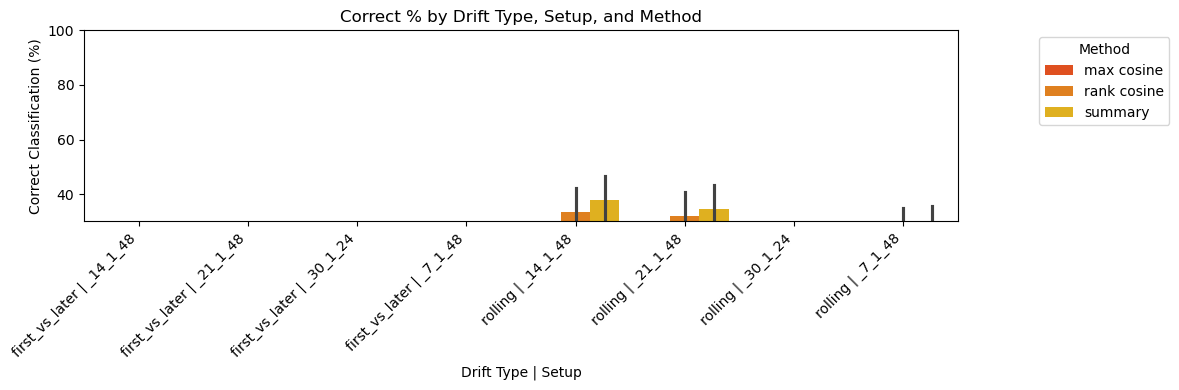

In [3]:
import random
from collections import defaultdict

def balanced_sample_per_class(folder_experiment, n_per_class):
    # 1. Group entries by class (A_, B_, C_, D_, E_)
    class_groups = defaultdict(list)
    for item in folder_experiment:
        filename = item.split('\\')[-1]  # get just the file part
        prefix = filename[:2]  # expects A_, B_, etc.
        if prefix in ['A_', 'B_', 'C_', 'D_', 'E_']:
            class_groups[prefix].append(item)

    # 2. Sample n items per class (if enough data is available)
    result = []
    for cls, items in class_groups.items():
        if len(items) < n_per_class:
            raise ValueError(f"Not enough items in class {cls}: needed {n_per_class}, found {len(items)}")
        result.extend(random.sample(items, n_per_class))

    return result



folders_experiment = [f for f in glob.glob(os.path.join('results/energy', '*BENCHMARK_ENERGY_2018*')) if os.path.isdir(f)]


results = analyze_experiments_by_epoch(data = folders_experiment, epochs = None)

import pickle
with open('results/imgs/experiment_benchmark_energy_analysis_test.pkl', 'wb') as f:
    pickle.dump(results, f)

possible_exps = set([exp.split('__')[-2] for exp in list(results.keys())])

setup_dict = {}
for setup in possible_exps:
    exps_setup = [exp for exp in list(results.keys()) if setup in exp]
    setup_dict[setup] = exps_setup

extraction_methods = [
    ("max cosine", extract_best_clients_by_max_cosine_distance),
    ("rank cosine", extract_best_clients_by_ranked_summary_initial),
    ("summary", extract_best_clients_by_summary_metrics)
]

results_evaluation, summary_df = evaluate_extraction_methods(setup_dict, results, extraction_methods)

import seaborn as sns
import matplotlib.pyplot as plt

# Create a combined category for drift_type and setup
results_evaluation['setup'] = results_evaluation['setup'].apply(
    lambda s: '_'.join(s.split('_')[:-1] + [str(int(int(s.split('_')[-1]) / 3600))])
)

results_evaluation['drift+setup'] = results_evaluation['drift_type'] + " | " + results_evaluation['setup']

plt.figure(figsize=(12, 4))
sns.barplot(
    data=results_evaluation,
    x='drift+setup',
    y='correct_%',
    hue='method',
    order = results_evaluation['drift+setup'].sort_values().unique(),
    palette='autumn'
)
plt.xticks(rotation=45, ha='right')
plt.ylim((30, 100))
plt.ylabel('Correct Classification (%)')
plt.xlabel('Drift Type | Setup')
plt.title('Correct % by Drift Type, Setup, and Method')
plt.legend(title='Method', bbox_to_anchor = (1.25,1))
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import os
import glob
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle

folders_experiment = [f for f in glob.glob(os.path.join('results/energy', '*BENCHMARK_ENERGY_2018*')) if os.path.isdir(f)]

with open('results/imgs/experiment_benchmark_energy_analysis.pkl', 'rb') as f:
    results = pickle.load(f)

possible_exps = set([exp.split('__')[-2] for exp in list(results.keys())])

setup_dict = {}
for setup in possible_exps:
    exps_setup = [exp for exp in list(results.keys()) if setup in exp]
    setup_dict[setup] = exps_setup

extraction_methods = [
    ("max cosine", extract_best_clients_by_max_cosine_distance),
    ("rank cosine", extract_best_clients_by_ranked_summary_initial),
    ("summary", extract_best_clients_by_summary_metrics)
]

results_evaluation, summary_df = evaluate_extraction_methods(setup_dict, results, extraction_methods)

_21_1_172800 - MAX COSINE
_21_1_172800 - RANK COSINE
_21_1_172800 - SUMMARY
_30_1_86400 - MAX COSINE
_30_1_86400 - RANK COSINE
_30_1_86400 - SUMMARY
_7_1_172800 - MAX COSINE
_7_1_172800 - RANK COSINE
_7_1_172800 - SUMMARY
_14_1_172800 - MAX COSINE
_14_1_172800 - RANK COSINE
_14_1_172800 - SUMMARY


In [77]:
results[folders_experiment[0]]['4']['feat_comp']['all_periods'].keys()

dict_keys(['mean', 'pairwise'])

In [121]:
results[folders_experiment[0]]['4']['feat_comp']['all_periods']['mean']

,client_id,label,compared_to,drift_type,cosine_distance,rank
0,District_A__proto,per_feature,mean_others,mean_vs_others_per_feature,0.021174,5.0
1,District_B__proto,per_feature,mean_others,mean_vs_others_per_feature,0.256908,1.0
2,District_C__proto,per_feature,mean_others,mean_vs_others_per_feature,0.059520,3.0
3,District_D__proto,per_feature,mean_others,mean_vs_others_per_feature,0.043494,4.0
4,District_E__proto,per_feature,mean_others,mean_vs_others_per_feature,0.243280,2.0


In [114]:
results[folders_experiment[0]]['4']['ranked']['all_periods']['summary']

,drift_type,client_id,mean_distance,sum_distance,rank_by_mean,rank_by_sum
0,first_vs_later,District_A__proto,0.210458,2.104581,3.0,3.0
1,first_vs_later,District_B__proto,0.195873,1.958727,5.0,5.0
2,first_vs_later,District_C__proto,0.210980,2.109803,2.0,2.0
3,first_vs_later,District_D__proto,0.208693,2.086930,4.0,4.0
4,first_vs_later,District_E__proto,0.229277,2.292766,1.0,1.0
5,rolling,District_A__proto,0.029512,0.295123,3.0,3.0
6,rolling,District_B__proto,0.028707,0.287070,4.0,4.0
7,rolling,District_C__proto,0.028517,0.285174,5.0,5.0
8,rolling,District_D__proto,0.030551,0.305510,2.0,2.0
9,rolling,District_E__proto,0.034152,0.341523,1.0,1.0


In [105]:
qwe_feat = results[folders_experiment[290]]['4']['feat_comp']['all_periods']['pairwise'].copy()
max_cosine_per_client = qwe_feat.loc[qwe_feat.groupby('client_id')['cosine_distance'].idxmax()]
max_cosine_per_client

,client_id,label,compared_to,drift_type,cosine_distance,rank
2,District_A__proto,per_feature,District_D__proto,per_feature_avg,0.004569,6.0
7,District_B__proto,per_feature,District_E__proto,per_feature_avg,0.007975,1.0
10,District_C__proto,per_feature,District_D__proto,per_feature_avg,0.005894,3.0
13,District_D__proto,per_feature,District_B__proto,per_feature_avg,0.006061,2.0
17,District_E__proto,per_feature,District_B__proto,per_feature_avg,0.007975,1.0


In [124]:
# qwe_feat = results[folders_experiment[29]]['4']['feat_comp']['all_periods']['pairwise'].copy()
# qwe_feat = qwe_feat.groupby('client_id').agg({'cosine_distance': 'mean'}).reset_index()
# qwe_feat = qwe_feat.loc[qwe_feat.groupby('client_id')['cosine_distance'].idxmax()]
qwe_feat = results[folders_experiment[20]]['4']['feat_comp']['all_periods']['mean'].copy()
qwe_feat['rank'] = qwe_feat['cosine_distance'].rank(method='dense', ascending=False)

qwe_comp = results[folders_experiment[20]]['4']['ranked']['all_periods']['summary'].copy()

qwe = pd.merge(qwe_comp, qwe_feat[['client_id', 'cosine_distance', 'rank']], on='client_id', how = 'left')

alpha = 0.5
qwe['new_metric'] = (1 - alpha)*qwe['mean_distance'] + (alpha)*qwe['cosine_distance']

qwe['new_rank'] = qwe.groupby('drift_type')['new_metric'].rank(method='dense', ascending=False)

qwe.sort_values(by='new_rank')

,drift_type,client_id,mean_distance,sum_distance,rank_by_mean,rank_by_sum,cosine_distance,rank,new_metric,new_rank
1,first_vs_later,District_B__proto,0.363299,3.632988,1.0,1.0,0.370509,1.0,0.366904,1.0
6,rolling,District_B__proto,0.047195,0.471948,2.0,2.0,0.370509,1.0,0.208852,1.0
4,first_vs_later,District_E__proto,0.352367,3.523669,3.0,3.0,0.208553,2.0,0.280460,2.0
9,rolling,District_E__proto,0.046752,0.467517,4.0,4.0,0.208553,2.0,0.127652,2.0
2,first_vs_later,District_C__proto,0.349673,3.496728,4.0,4.0,0.167936,3.0,0.258804,3.0
7,rolling,District_C__proto,0.046908,0.469075,3.0,3.0,0.167936,3.0,0.107422,3.0
0,first_vs_later,District_A__proto,0.341600,3.416001,5.0,5.0,0.164910,4.0,0.253255,4.0
5,rolling,District_A__proto,0.044862,0.448625,5.0,5.0,0.164910,4.0,0.104886,4.0
3,first_vs_later,District_D__proto,0.355773,3.557733,2.0,2.0,0.083721,5.0,0.219747,5.0
8,rolling,District_D__proto,0.047902,0.479017,1.0,1.0,0.083721,5.0,0.065811,5.0


In [ ]:
def compute_client_vs_others_pairwise(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    # Ensure label order
    data_latent = data_latent.sort_values(['client_id', 'label'])

    # Group all client trajectories
    client_trajectories = {}
    for client_id, group in data_latent.groupby('client_id'):
        vectors = group[features].values  # shape: (num_labels, num_features)
        if len(vectors) < 2:
            continue  # skip clients with too few labels
        trajectory = vectors.flatten()  # shape: (num_labels * num_features,)
        client_trajectories[client_id] = trajectory.reshape(1, -1)

    clients = list(client_trajectories.keys())

    for i, client_a in enumerate(clients):
        traj_a = client_trajectories[client_a]

        for j, client_b in enumerate(clients):
            if i == j:
                continue
            traj_b = client_trajectories[client_b]
            dist = cosine_distances(traj_a, traj_b)[0][0]
            results.append({
                'client_id': client_a,
                'compared_to': client_b,
                'drift_type': 'pairwise_vs_others_time',
                'cosine_distance': dist
            })

    return pd.DataFrame(results)

def compute_client_vs_others_pairwise_per_feature(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    data_latent = data_latent.sort_values(['client_id', 'label'])

    client_features = {}
    for client_id, group in data_latent.groupby('client_id'):
        traj = group[features].values.T  # shape: (n_features, n_labels)
        if traj.shape[1] < 2:
            continue
        client_features[client_id] = traj

    clients = list(client_features.keys())
    for i, client_a in enumerate(clients):
        traj_a = client_features[client_a]

        for j, client_b in enumerate(clients):
            if i == j:
                continue
            traj_b = client_features[client_b]
            distances = [
                cosine_distances(traj_a[f].reshape(1, -1), traj_b[f].reshape(1, -1))[0][0]
                for f in range(traj_a.shape[0])
            ]
            avg_dist = np.mean(distances)
            results.append({
                'client_id': client_a,
                'compared_to': client_b,
                'drift_type': 'per_feature_avg',
                'cosine_distance': avg_dist
            })

    return pd.DataFrame(results)



def compute_client_vs_others_mean(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    data_latent = data_latent.sort_values(['client_id', 'label'])

    # Build trajectories
    client_trajectories = {}
    for client_id, group in data_latent.groupby('client_id'):
        vectors = group[features].values
        if len(vectors) < 2:
            continue
        trajectory = vectors.flatten()
        client_trajectories[client_id] = trajectory.reshape(1, -1)

    clients = list(client_trajectories.keys())

    for client_id in clients:
        traj = client_trajectories[client_id]
        others = [v for k, v in client_trajectories.items() if k != client_id]
        if not others:
            continue
        mean_traj = np.mean(np.vstack(others), axis=0).reshape(1, -1)
        dist = cosine_distances(traj, mean_traj)[0][0]
        results.append({
            'client_id': client_id,
            'compared_to': 'mean_others',
            'drift_type': 'mean_vs_others_time',
            'cosine_distance': dist
        })

    return pd.DataFrame(results)


def compute_client_vs_others_mean_per_feature(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    # Ensure label ordering for consistency
    data_latent = data_latent.sort_values(['client_id', 'label'])

    # Build time-series per feature: shape (n_features, n_labels)
    client_trajectories = {}
    for client_id, group in data_latent.groupby('client_id'):
        feature_matrix = group[features].values.T  # (n_features, n_labels)
        if feature_matrix.shape[1] < 2:
            continue
        client_trajectories[client_id] = feature_matrix

    clients = list(client_trajectories.keys())
    for client_id in clients:
        traj = client_trajectories[client_id]  # shape (f, t)
        others = [v for k, v in client_trajectories.items() if k != client_id]
        if not others:
            continue

        # Compute mean trajectory across others (shape: f x t)
        mean_others = np.mean(np.stack(others), axis=0)

        # Cosine per feature
        cosine_per_feature = [
            cosine_distances(traj[f].reshape(1, -1), mean_others[f].reshape(1, -1))[0][0]
            for f in range(traj.shape[0])
        ]
        mean_distance = np.mean(cosine_per_feature)

        results.append({
            'client_id': client_id,
            'compared_to': 'mean_others',
            'drift_type': 'mean_vs_others_per_feature',
            'cosine_distance': mean_distance
        })

    return pd.DataFrame(results)


def compute_client_drift_trajectory(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    drift_trajectories = []

    for client_id, group in data_latent.groupby('client_id'):
        group = group.sort_values('label')
        vectors = group[features].values
        labels = group['label'].values

        distances = [0]  # First label has no previous
        for i in range(1, len(vectors)):
            dist = cosine_distances(vectors[i-1].reshape(1, -1), vectors[i].reshape(1, -1))[0][0]
            distances.append(dist)

        drift_trajectories.append(pd.DataFrame({
            'client_id': client_id,
            'label': labels,
            'cosine_change': distances
        }))

    return pd.concat(drift_trajectories)


def extract_best_clients_by_external_comparison(experiments_dict, mode='pairwise_flat'):
    """
    Extract clients that most frequently rank highest in external drift comparison.

    Parameters:
        experiments_dict (dict): results[experiment][epoch]['latent_data'][period]
        mode (str): One of 'pairwise_flat', 'mean_flat', 'pairwise_feature', 'mean_feature', 'trajectory'

    Returns:
        pd.DataFrame: Top drifting clients per drift_type per experiment and period
    """
    assert mode in ['pairwise_flat', 'mean_flat', 'pairwise_feature', 'mean_feature', 'trajectory'], \
        f"Invalid mode '{mode}'"

    # Select appropriate drift computation function
    if mode == 'pairwise_flat':
        compute_fn = compute_client_vs_others_pairwise
    elif mode == 'mean_flat':
        compute_fn = compute_client_vs_others_mean
    elif mode == 'pairwise_feature':
        compute_fn = compute_client_vs_others_pairwise_per_feature  # You may rename this if needed
    elif mode == 'mean_feature':
        compute_fn = compute_client_vs_others_mean_per_feature



    periods = {
        # 'first_4_months': list(range(0, 4)),
        # 'middle_year': list(range(4, 8)),
        # 'final_year': list(range(9, 12)),
        'all_periods': list(range(0, 12))
    }


    top_clients_all_experiments = []

    for experiment_name, experiment_list in experiments_dict.items():

        for experiment in experiment_list:
            # Load and filter data
            data_path = os.path.join(experiment, 'Baseline_latent_space.parquet')
            new_latent = pd.read_parquet(data_path)
            new_latent = new_latent[new_latent['client_id'].str.contains('_proto')]

            # Iterate over epochs
            epochs_loop = new_latent['epoch'].sort_values().unique()
            top_rows_per_epoch = []
            for epoch in epochs_loop:

                data_epoch = new_latent[new_latent['epoch'].astype(str) == str(epoch)]

                # Iterate over target periods
                for period_id, valid_labels in periods.items():
                    df_period = data_epoch[data_epoch['label'].isin(valid_labels)]

                    # Compute drift metrics
                    df_drift = compute_fn(df_period)
                    if df_drift.empty:
                        print('Warning empty df_drift!!')
                        continue


                    # External drift (vs others or mean)
                    df_summary = (
                        df_drift.groupby('client_id')['cosine_distance']
                        .mean()
                        .reset_index()
                    )
                    drift_type = df_drift['drift_type'].iloc[0]
                    df_summary['drift_type'] = drift_type

                    # Rank and select top clients
                    df_summary['rank'] = df_summary.groupby('drift_type')['cosine_distance']\
                                                   .rank(method='dense', ascending=False)
                    top_rank_df = df_summary[df_summary['rank'] == 1].copy()
                    top_rank_df['epoch'] = epoch
                    top_rank_df['period'] = period_id
                    top_rank_df['experiment'] = experiment
                    top_rows_per_epoch.append(top_rank_df)

            # === Post-Epoch Aggregation ===
            if not top_rows_per_epoch:
                print(f'Warning, no data computed for any epoch!! -> Exp: {experiment}')
                continue

            combined_df = pd.concat(top_rows_per_epoch, ignore_index=True)
            count_df = (
                combined_df.groupby(['experiment', 'drift_type', 'period', 'client_id'])
                .size()
                .reset_index(name='count')
            )
            max_counts = count_df.groupby(['experiment', 'drift_type', 'period'])['count'].transform('max')
            top_clients_df = count_df[count_df['count'] == max_counts].copy()


            # top_clients_df['experiment'] = experiment
            # top_clients_df['period'] = period_id
            top_clients_all_experiments.append(top_clients_df)

    final_df = pd.concat(top_clients_all_experiments, ignore_index=True)

    # Add diagnostics
    final_df['client_drift'] = final_df['client_id'].str.split('_').str[1]
    final_df['ground_truth'] = 'D'  # Optional: replace with true label if you have it
    final_df['check'] = final_df['client_drift'] == final_df['ground_truth']

    return final_df

In [ ]:
folders_experiment = [f for f in glob.glob(os.path.join('results/energy', '*BENCHMARK_ENERGY_2018*')) if os.path.isdir(f)]

possible_exps = set([exp.split('__')[-2] for exp in list(folders_experiment)])

setup_dict = {}
for setup in possible_exps:
    exps_setup = [exp for exp in folders_experiment if setup in exp]
    setup_dict[setup] = exps_setup

In [ ]:
results_drift_feats = []
for mode in ['pairwise_flat', 'mean_flat', 'pairwise_feature', 'mean_feature']:
    aux_feats = extract_best_clients_by_external_comparison(experiments_dict = setup_dict, mode=mode)
    results_drift_feats.append(aux_feats)

results_drift_feats

In [ ]:
# import pickle
#
# with open('results/imgs/Bench_energy_drift_feats.pkl', 'wb') as f:
#     pickle.dump(results_drift_feats, f)


In [65]:
import pickle

with open('results/imgs/Bench_energy_drift_feats.pkl', 'rb') as f:
    results_drift_feats = pickle.load(f)

In [66]:
df_feats = results_drift_feats[-2].copy()
df_feats['exp_id'] = df_feats['experiment'].str[15:24]
df_feats['setup'] = df_feats['experiment'].str.split('___').str[1]
df_feats.drop(columns = 'experiment', inplace = True)

df_feats[['drift_interval', 'drift_power', 'feats']] = df_feats['exp_id'].str.split('_', expand = True)

df_feats.head()

,drift_type,period,client_id,count,client_drift,ground_truth,check,exp_id,setup,drift_interval,drift_power,feats
0,per_feature_avg,all_periods,District_E__proto,3,E,D,False,P1_s+05_1,30_1_86400,P1,s+05,1
1,per_feature_avg,final_year,District_A__proto,4,A,D,False,P1_s+05_1,30_1_86400,P1,s+05,1
2,per_feature_avg,first_4_months,District_E__proto,3,E,D,False,P1_s+05_1,30_1_86400,P1,s+05,1
3,per_feature_avg,middle_year,District_B__proto,4,B,D,False,P1_s+05_1,30_1_86400,P1,s+05,1
4,per_feature_avg,all_periods,District_E__proto,4,E,D,False,P1_s+05_2,30_1_86400,P1,s+05,2


In [75]:
df_feats[df_feats['check']][['period','setup']].value_counts()

period          setup      
first_4_months  30_1_86400     10
                21_1_172800     8
final_year      7_1_172800      7
all_periods     30_1_86400      3
final_year      21_1_172800     3
first_4_months  14_1_172800     3
                7_1_172800      3
final_year      14_1_172800     1
middle_year     30_1_86400      1
Name: count, dtype: int64

In [74]:
df_count = df_feats[df_feats['setup'] == '30_1_86400']
df_count[df_count['check']][['period', 'exp_id']].value_counts()

period          exp_id   
all_periods     P1_s+20_1    1
                P2_s-20_1    1
                P3_s+20_1    1
first_4_months  P1_s+20_1    1
                P1_s+20_4    1
                P2_s+20_4    1
                P2_s-10_1    1
                P2_s-20_1    1
                P2_s-20_2    1
                P2_s-20_4    1
                P2_s-20_5    1
                P3_s+20_4    1
                P3_s+20_5    1
middle_year     P3_s+20_4    1
Name: count, dtype: int64

In [ ]:
df_feats[df_feats['check'] & (df_feats['exp_id'] == 'P2_s-20_4')]

In [ ]:
exp = 'results/energy\P1_s+05_1feats_5_2_24_30_BENCHMARK_ENERGY_2018___30_1_86400___0'
data_path = os.path.join(exp, 'Baseline_latent_space.parquet')
new_latent = pd.read_parquet(data_path)
new_latent = new_latent[new_latent['client_id'].str.contains('_proto')]

epochs_loop = new_latent['epoch'].sort_values().unique()
top_rows_per_epoch = []
for epoch in epochs_loop:

    data_epoch = new_latent[new_latent['epoch'].astype(str) == epoch]

    df_period = data_epoch[data_epoch['label'].isin(list(range(9, 12)))]

    df_drift = compute_client_vs_others_pairwise(df_period)

    df_summary = (
        df_drift.groupby('client_id')['cosine_distance']
        .mean()
        .reset_index()
    )
    drift_type = df_drift['drift_type'].iloc[0]
    df_summary['drift_type'] = drift_type

    df_summary['rank'] = df_summary.groupby('drift_type')['cosine_distance']\
                                   .rank(method='dense', ascending=False)

    top_rank_df = df_summary[df_summary['rank'] == 1].copy()
    top_rank_df['epoch'] = epoch
    top_rank_df['period'] = 'final_year'
    top_rank_df['experiment'] = exp
    top_rows_per_epoch.append(top_rank_df)


combined_df = pd.concat(top_rows_per_epoch, ignore_index=True)
count_df = (
    combined_df.groupby(['experiment', 'drift_type', 'period', 'client_id'])
    .size()
    .reset_index(name='count')
)
max_counts = count_df.groupby(['experiment', 'drift_type', 'period'])['count'].transform('max')
top_clients_df = count_df[count_df['count'] == max_counts].copy()

top_clients_df

In [ ]:
# Compute drift metrics
df_drift = compute_fn(df_period)
if df_drift.empty:
    print('Warning empty df_drift!!')
    continue


# External drift (vs others or mean)
df_summary = (
    df_drift.groupby('client_id')['cosine_distance']
    .mean()
    .reset_index()
)
drift_type = df_drift['drift_type'].iloc[0]
df_summary['drift_type'] = drift_type

# Rank and select top clients
df_summary['rank'] = df_summary.groupby('drift_type')['cosine_distance']\
                               .rank(method='dense', ascending=False)
top_rank_df = df_summary[df_summary['rank'] == 1].copy()
top_rank_df['epoch'] = epoch
top_rank_df['period'] = period_id
top_rank_df['experiment'] = experiment
top_rows_per_epoch.append(top_rank_df)

In [3]:
import pandas as pd
import os
import glob
from collections import defaultdict

file_paths_a = glob.glob(f'data_leaks/benchmark/energy/R*')
file_paths_b = glob.glob(f'data_leaks/benchmark/energy/P*')

file_paths = file_paths_a + file_paths_b
file_paths = [f for f in file_paths if 's-' in f]
file_paths

['data_leaks/benchmark/energy\\R1_s-15_1feats',
 'data_leaks/benchmark/energy\\R1_s-15_2feats',
 'data_leaks/benchmark/energy\\R1_s-15_3feats',
 'data_leaks/benchmark/energy\\R1_s-15_4feats',
 'data_leaks/benchmark/energy\\R1_s-15_5feats',
 'data_leaks/benchmark/energy\\R1_s-15_6feats',
 'data_leaks/benchmark/energy\\R1_s-30_1feats',
 'data_leaks/benchmark/energy\\R1_s-30_2feats',
 'data_leaks/benchmark/energy\\R1_s-30_3feats',
 'data_leaks/benchmark/energy\\R1_s-30_4feats',
 'data_leaks/benchmark/energy\\R1_s-30_5feats',
 'data_leaks/benchmark/energy\\R1_s-30_6feats',
 'data_leaks/benchmark/energy\\R1_s-40_1feats',
 'data_leaks/benchmark/energy\\R1_s-40_2feats',
 'data_leaks/benchmark/energy\\R1_s-40_3feats',
 'data_leaks/benchmark/energy\\R1_s-40_4feats',
 'data_leaks/benchmark/energy\\R1_s-40_5feats',
 'data_leaks/benchmark/energy\\R1_s-40_6feats',
 'data_leaks/benchmark/energy\\R2_s-15_1feats',
 'data_leaks/benchmark/energy\\R2_s-15_2feats',
 'data_leaks/benchmark/energy\\R2_s-15_3

_30_1_24


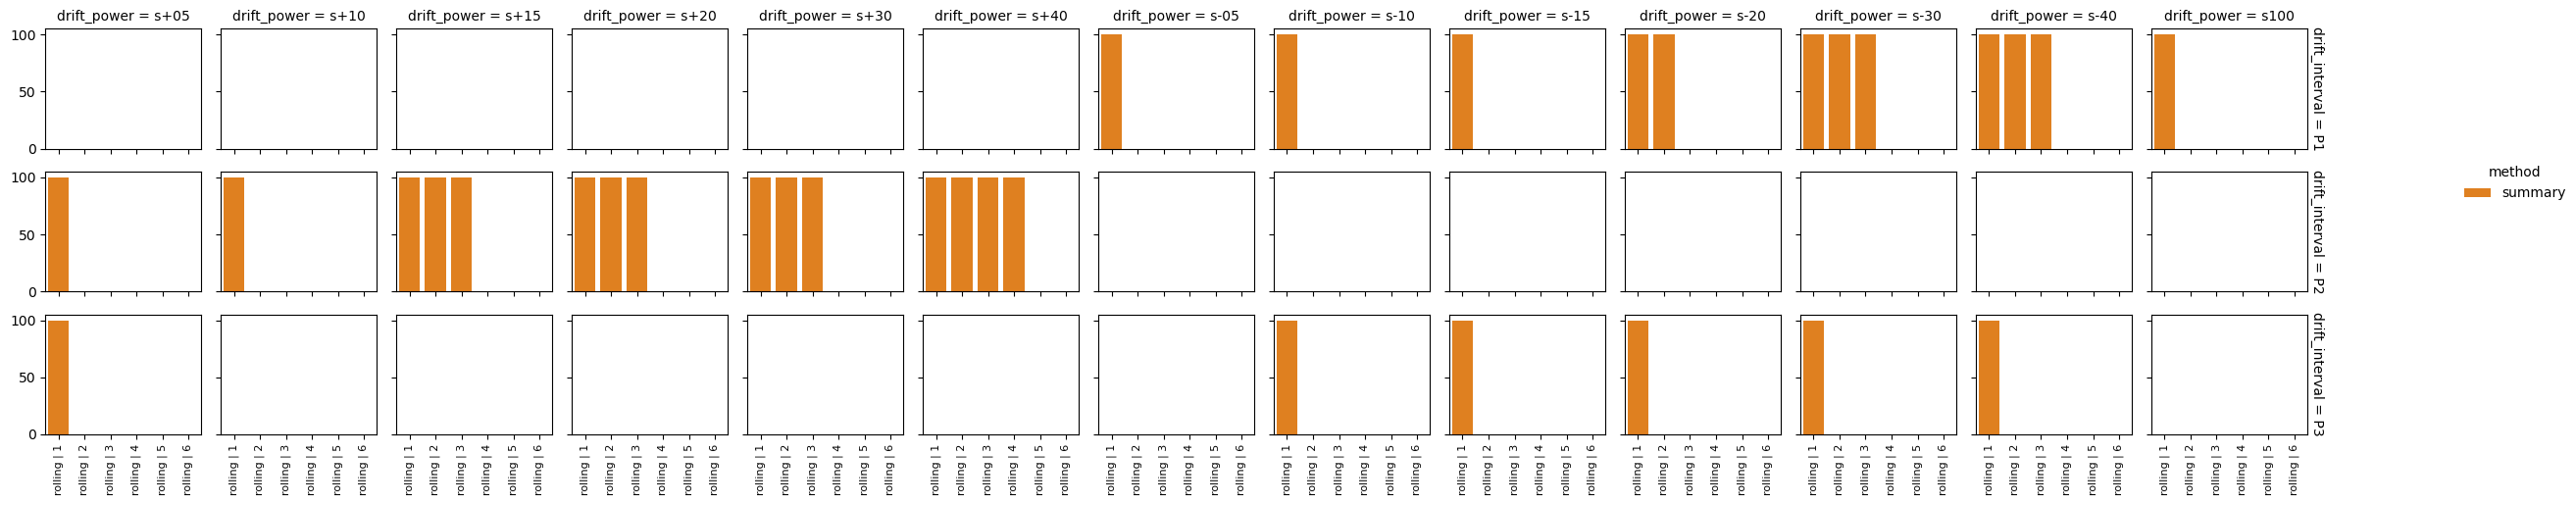

_21_1_48


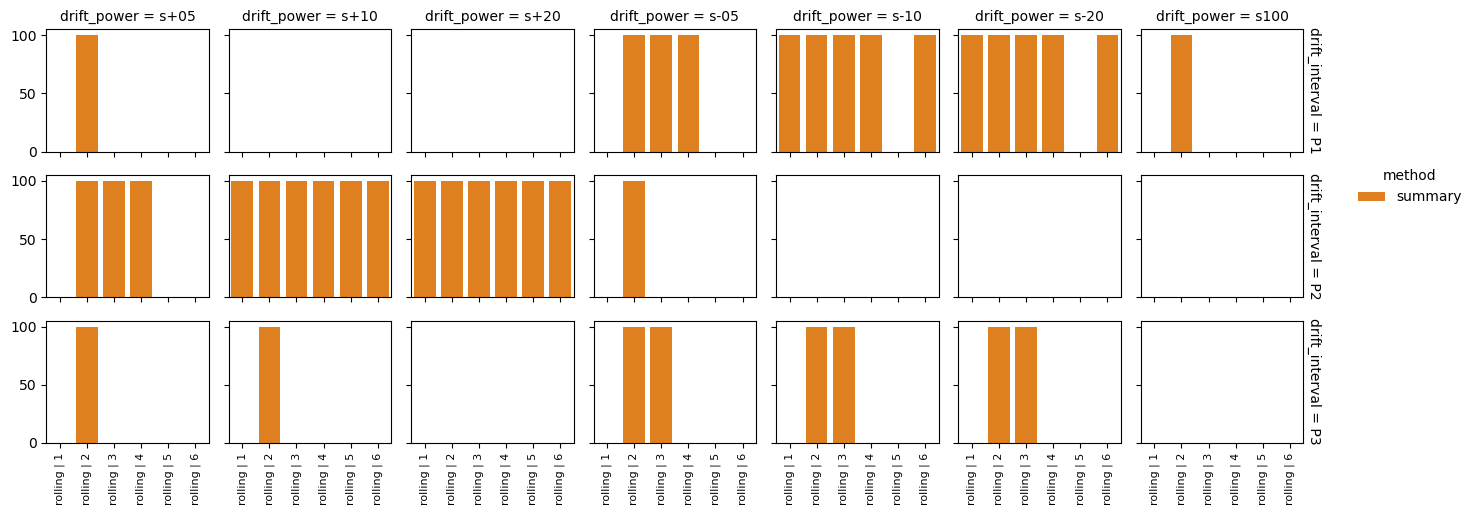

_7_1_48


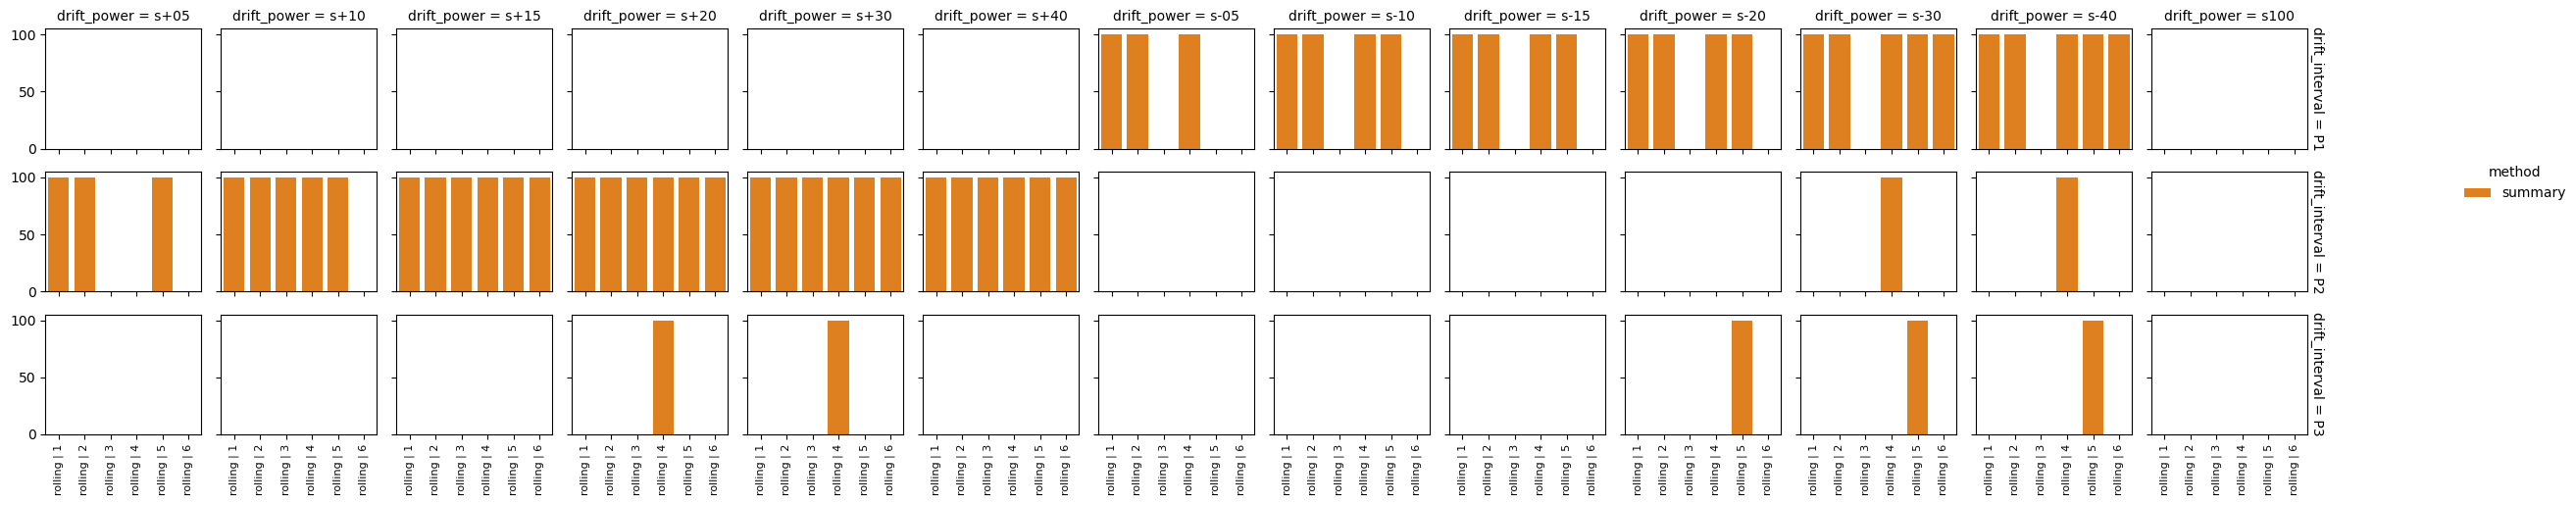

_14_1_48


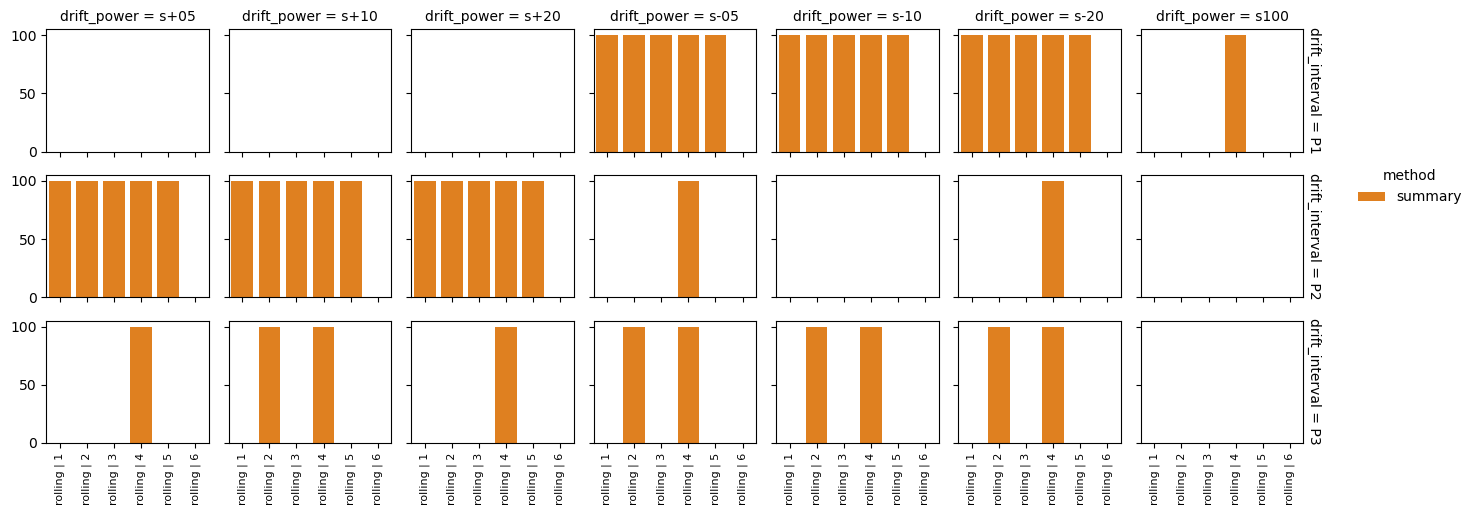

In [11]:
# data_exp = results_evaluation[results_evaluation['setup'] == '_30_1_86400'].copy()
# data_exp = results_evaluation.copy()
data_exp = results_evaluation[results_evaluation['drift_type'] == 'rolling'].copy()
data_exp[['drift_interval', 'drift_power', 'feats']] = data_exp['exp_id'].str.replace('R', 'P').str.split('_', expand = True)

for setup in data_exp['setup'].unique():
    print(setup)
    data_exp_0 = data_exp[data_exp['period'] == 'all_year'].copy()
    data_exp_0 = data_exp_0[data_exp_0['setup'] == setup]
    
    x_var = 'drift_exp'
    # data_exp_0[x_var] = data_exp_0['drift_type'] + " | " + data_exp_0['drift_power'] + " | " + data_exp_0['feats']
    data_exp_0[x_var] = data_exp_0['drift_type'] + " | " + data_exp_0['feats']
    
    col_var = 'drift_power'
    row_var = 'drift_interval'
    hue_var = 'method'
    
    # Define FacetGrid with tighter spacing
    g = sns.FacetGrid(
        data_exp_0,
        col=col_var,
        row=row_var,
        col_order=data_exp_0[col_var].sort_values().unique(),
        row_order=data_exp_0[row_var].sort_values().unique(),
        margin_titles=True,        # Helps use space better
        despine=False,             # Keeps axes for reference
        height=1.75,                # Smaller subplot height
        aspect=1                   # Adjust aspect ratio (width / height)
    )
    
    # Map barplot with narrower bars
    g.map_dataframe(
        sns.barplot,
        x=x_var,
        y='correct_%',
        # order=data_exp_0[x_var].sort_values().unique(),
        hue=hue_var,
        hue_order=data_exp_0[hue_var].sort_values().unique(),
        width=.8,
        palette='autumn'
    )
    
    # Reduce spacing between subplots
    g.fig.subplots_adjust(
        hspace=0.2,  # vertical space between rows
        wspace=0.05  # horizontal space between columns
    )
    
    # Reduce legend size and move to a compact position
    g.add_legend(title=hue_var)
    g._legend.set_bbox_to_anchor((1.10, 0.625))  # move legend to side
    g._legend.set_frame_on(False)
    
    # Optional: Rotate x-ticks and tighten layout
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(90)
            label.set_fontsize(8)
        ax.set_ylabel('')
        ax.set_xlabel('')
    
    
    plt.tight_layout()
    plt.show()


s+05


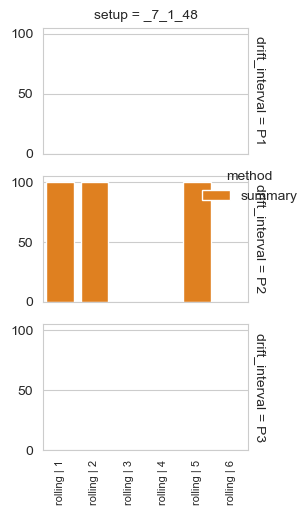


s+10


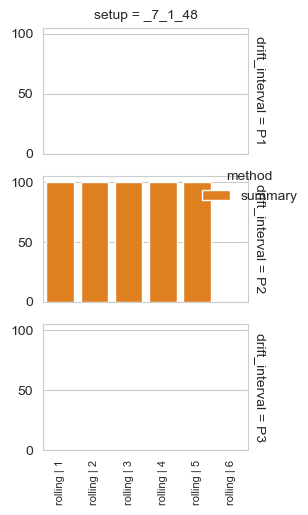


s+20


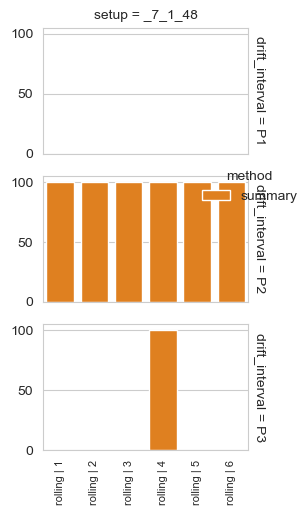


s-05


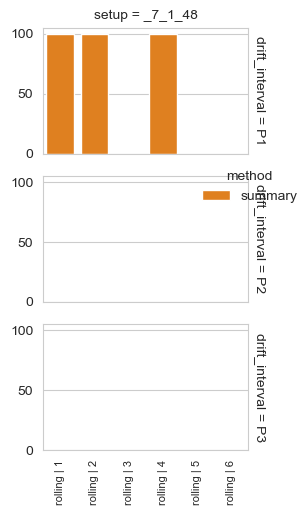


s-10


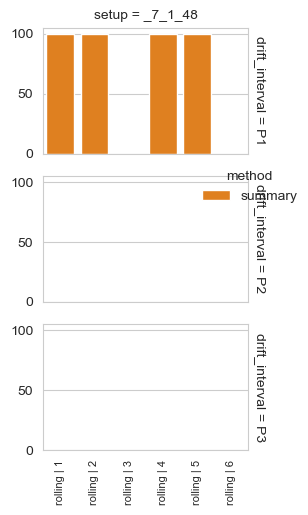


s-20


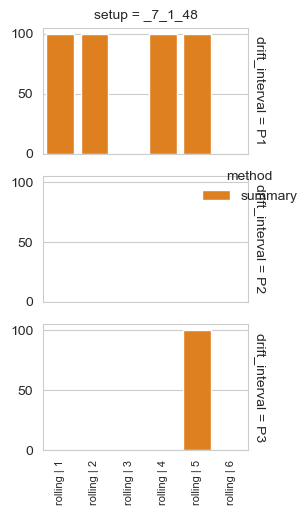


s100


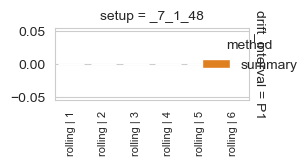


s+15


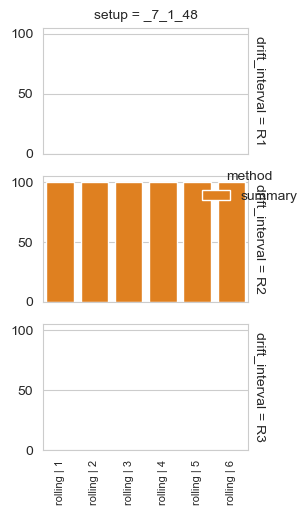


s+30


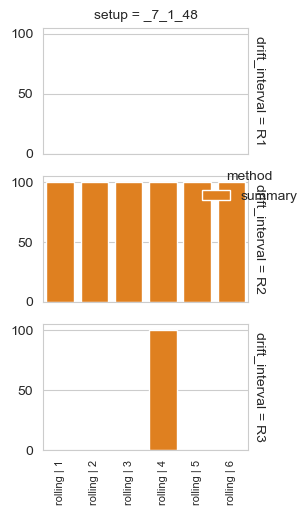


s+40


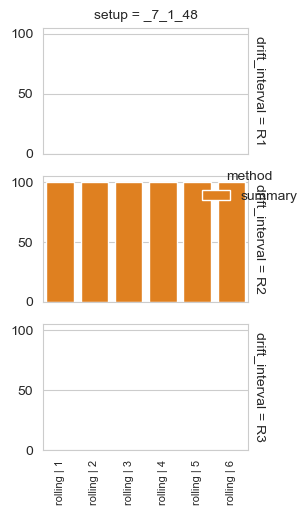


s-15


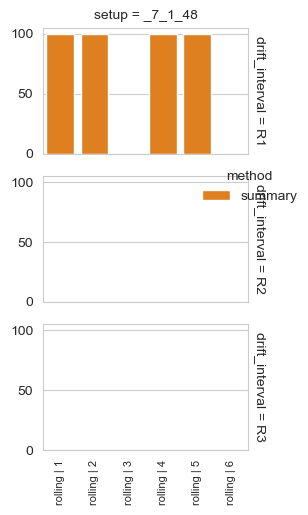


s-30


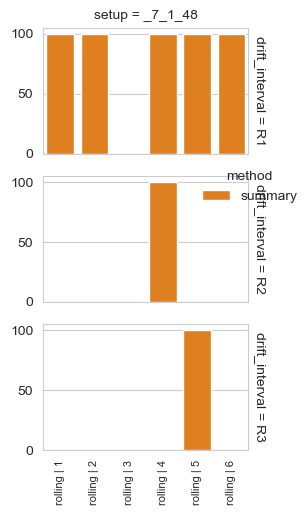


s-40


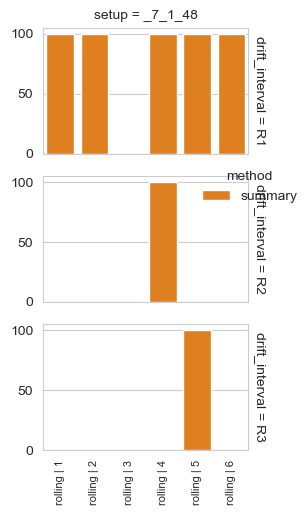

In [153]:
# data_exp = results_evaluation[results_evaluation['setup'] == '_30_1_86400'].copy()
# data_exp = results_evaluation.copy()
data_exp = results_evaluation[results_evaluation['drift_type'] == 'rolling'].copy()
data_exp[['drift_interval', 'drift_power', 'feats']] = data_exp['exp_id'].str.split('_', expand = True)

for power in data_exp['drift_power'].unique():
    data_exp_0 = data_exp[data_exp['drift_power'] == power].copy()
    data_exp_0 = data_exp_0[data_exp_0['period'] == 'all_year']
    print(f'\n{power}')

    x_var = 'drift_exp'
    # data_exp_0[x_var] = data_exp_0['drift_type'] + " | " + data_exp_0['drift_power'] + " | " + data_exp_0['feats']
    data_exp_0[x_var] = data_exp_0['drift_type'] + " | " + data_exp_0['feats']

    col_var = 'setup'
    row_var = 'drift_interval'
    hue_var = 'method'

    # Define FacetGrid with tighter spacing
    g = sns.FacetGrid(
        data_exp_0,
        col=col_var,
        row=row_var,
        col_order=data_exp_0[col_var].sort_values().unique(),
        row_order=data_exp_0[row_var].sort_values().unique(),
        margin_titles=True,        # Helps use space better
        despine=False,             # Keeps axes for reference
        height=1.75,                # Smaller subplot height
        aspect=1                   # Adjust aspect ratio (width / height)
    )

    # Map barplot with narrower bars
    g.map_dataframe(
        sns.barplot,
        x=x_var,
        y='correct_%',
        # order=data_exp_0[x_var].sort_values().unique(),
        hue=hue_var,
        hue_order=data_exp_0[hue_var].sort_values().unique(),
        width=.8,
        palette='autumn'
    )

    # Reduce spacing between subplots
    g.fig.subplots_adjust(
        hspace=0.2,  # vertical space between rows
        wspace=0.05  # horizontal space between columns
    )

    # Reduce legend size and move to a compact position
    g.add_legend(title=hue_var)
    g._legend.set_bbox_to_anchor((1.10, 0.625))  # move legend to side
    g._legend.set_frame_on(False)

    # Optional: Rotate x-ticks and tighten layout
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(90)
            label.set_fontsize(8)
        ax.set_ylabel('')
        ax.set_xlabel('')


    plt.tight_layout()
    plt.show()

In [ ]:
data_exp_0[(data_exp_0['feats'] == '3') & (data_exp_0['period'] == 'first_4_months')].sort_values(by=['drift_type', 'method'])

In [ ]:
data_exp_0[(data_exp_0['setup'] == '_21_1_48') & (data_exp_0['method'] == 'max cosine')].sort_values(by=['drift_type', 'method'])

In [ ]:
data_exp_0.groupby(['setup', 'method', 'exp_id']).agg({'correct_%' : 'sum'})

In [ ]:
sum_df = summary_df[1].copy()

sum_df['exp_id'] = sum_df['experiment'].str[8:15]

crosstab = (
    pd.crosstab([sum_df['exp_id'], sum_df['drift_type']], sum_df['check'], normalize='index') * 100
).round(2)

crosstab.rename(columns={True: 'correct_%', False: 'wrong_%'}, inplace=True)
crosstab

In [ ]:
Traceback (most recent call last):
  File "C:\Users\arthu\USPy\0_BEPE\2_FeDomain\Run_Experiment.py", line 108, in <module>
    main()
  File "C:\Users\arthu\USPy\0_BEPE\2_FeDomain\Run_Experiment.py", line 66, in main
    train(model=model,
  File "C:\Users\arthu\USPy\0_BEPE\2_FeDomain\utils\Server.py", line 36, in train
    epoch_loc_loss_dict = model.loc_update(priloader_list = private_train_loaders,
  File "C:\Users\arthu\USPy\0_BEPE\2_FeDomain\models\fpl.py", line 168, in loc_update
    self._train_net(i, self.nets_list[i], priloader_list[i], prilabel_list[i])
  File "C:\Users\arthu\USPy\0_BEPE\2_FeDomain\models\fpl.py", line 258, in _train_net
    data_loader = model.prepare_data(X = train_loader, X_index = label_loader)
  File "C:\Users\arthu\USPy\0_BEPE\2_FeDomain\backbone\AER.py", line 171, in prepare_data
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=self.shuffle)
  File "C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\torch\utils\data\dataloader.py", line 376, in __init__
    sampler = RandomSampler(dataset, generator=generator)  # type: ignore[arg-type]
  File "C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\torch\utils\data\sampler.py", line 164, in __init__
    raise ValueError(
ValueError: num_samples should be a positive integer value, but got num_samples=0
(TsLeaks) PS C:\Users\arthu\USPy\0_BEPE\2_FeDomain>


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from capymoa.stream.drift import DriftStream, AbruptDrift, GradualDrift
from capymoa.stream.generator import SEA

# Define the drift stream
stream_sea2drift = DriftStream(
    stream=[
        SEA(function=1),
        AbruptDrift(position=50),
        SEA(function=1),
        GradualDrift(position=100, width=250),
        # GradualDrift(start=9000, end=12000),
        SEA(function=1),
    ]
)

stream_sea2drift = DriftStream(stream=[
    SEA(function=1),                      # Concept B
    # GradualDrift(start=300, end=800),
    AbruptDrift(position=50),
    SEA(function=1),                      # Concept C
])

# Collect data
data = []
num_instances = 10000  # Feel free to increase for longer plots

for i, instance in enumerate(stream_sea2drift):
    x = instance.x
    data.append(x)
    if i >= num_instances - 1:
        break

# After collecting `data` from the stream
df = pd.DataFrame(data, columns=["f0", "f1", "f2"])

# Add timestamps (5-min steps)
start_time = datetime(2024, 1, 1, 0, 0)
df["timestamp"] = [start_time + timedelta(minutes=5 * i) for i in range(len(df))]

# Set index
df.set_index("timestamp", inplace=True)

# Aggregate (1 hour)
agg_df = df.resample("2h").mean()

# Plot
plt.figure(figsize=(12, 6))
for col in ["f0", "f1"]:
    plt.plot(agg_df.index, agg_df[col], label=col)

plt.title("SEA Feature Values Over Time (1-Hour Aggregation)")
plt.xlabel("Time")
plt.ylabel("Feature Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from capymoa.stream.drift import DriftStream, AbruptDrift, GradualDrift
from capymoa.stream.generator import SEA
from capymoa.classifier import OnlineBagging
from capymoa.evaluation import prequential_evaluation
from capymoa.evaluation.visualization import plot_windowed_results

stream_sea2drift = DriftStream(
    stream=[
        SEA(function=1),
        AbruptDrift(position=50),
        SEA(function=3),
        GradualDrift(position=100, width=200),
        # GradualDrift(start=9000, end=12000),
        SEA(function=1),
    ]
)

OB = OnlineBagging(schema=stream_sea2drift.get_schema(), ensemble_size=10)

results_sea2drift_OB = prequential_evaluation(
    stream=stream_sea2drift, learner=OB, window_size=10, max_instances=300
)

print(
    f"The definition of the DriftStream is accessible through the object:\n {stream_sea2drift}"
)
plot_windowed_results(results_sea2drift_OB, metric="accuracy")

In [ ]:
import pandas as pd

In [ ]:
data_linear = pd.read_csv('data_leaks/benchmark/Simulator/linear_gradual_rotation_noise_and_redunce.csv')
data_linear

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import imageio
import os

# --- Load your data ---
# Replace with your real dataset
# df = pd.read_csv('your_file.csv')
# Assume df has columns ['x1', 'x2', 'x3', 'x4', 'x5', 'label']

# For safety: reset index
df = data_linear.reset_index(drop=True)
df = df.iloc[:20000, :]
# Features and label
features = ['x1', 'x2']

# --- Create a temporary directory for frames ---
os.makedirs("frames", exist_ok=True)
frame_paths = []

# --- Create PCA plots in steps ---
step = 1000
for i in range(step, len(df)+1, step):
    df_subset = df.iloc[i - step:i]

    X = df_subset[features]
    y = df_subset['label']

    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Combine into DataFrame for plotting
    df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_pca['label'] = y.values

    # Plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_subset, x='x1', y='x2', hue='label', palette='Set1', s=50)

    plt.title(f'PCA Plot (First {i} Points)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.grid(True)
    plt.tight_layout()

    # Save frame
    frame_path = f"results/imgs/frames/frame_{i}.png"
    plt.savefig(frame_path)
    frame_paths.append(frame_path)
    plt.close()

# --- Create the GIF ---
gif_path = "pca_animation.gif"
with imageio.get_writer(gif_path, mode='I', duration=0.8) as writer:
    for frame_path in frame_paths:
        image = imageio.imread(frame_path)
        writer.append_data(image)

print(f"✅ GIF saved to: {gif_path}")


In [ ]:
data_linear = pd.read_csv('data_leaks/benchmark/Simulator/linear_gradual_rotation_noise_and_redunce.csv')
data_linear.reset_index(inplace = True)
data_linear = data_linear.iloc[:1000, :]
data_linear = data_linear[data_linear['label'] == 0]
df_linear_melted = data_linear.melt(id_vars=['index', 'label'], value_vars=['x1'],
                    var_name='feature', value_name='value')

data_nonlinear = pd.read_csv('data_leaks/benchmark/Simulator/nonlinear_gradual_cakerotation_noise_and_redunce.csv')
data_nonlinear.reset_index(inplace = True)
data_nonlinear = data_nonlinear.iloc[:1000, :]
data_nonlinear = data_nonlinear[data_nonlinear['label'] == 0]
df_nonlinear_melted = data_nonlinear.melt(id_vars=['index', 'label'], value_vars=['x1'],
                    var_name='feature', value_name='value')

In [ ]:
# Add 'case' column to each melted DataFrame
df_linear_melted['case'] = 'linear'
df_nonlinear_melted['case'] = 'nonlinear'

# Combine the two datasets
df_combined = pd.concat([df_linear_melted, df_nonlinear_melted], ignore_index=True)

# Create the lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_combined,
    x='index',
    y='value',
    hue='case',
    style='feature',
    markers=True
)

plt.title('Feature Trends (Linear vs Nonlinear)')
plt.xlabel('Index')
plt.ylabel('Feature Value')
plt.grid(True)
plt.tight_layout()
plt.show()